Shape: (1305, 9554)


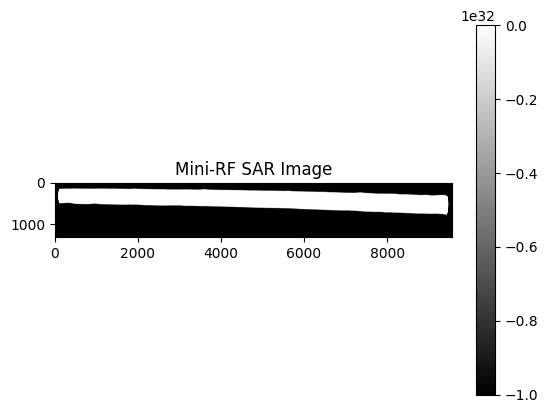

In [1]:
import rasterio
import matplotlib.pyplot as plt

# Load your GeoTIFF
file_path = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"

with rasterio.open(file_path) as src:
    data = src.read(1)  # read first band

print("Shape:", data.shape)

# Display
plt.imshow(data, cmap='gray')
plt.colorbar()
plt.title("Mini-RF SAR Image")
plt.show()

C:\Users\karna\AppData\Local\Temp\ipykernel_22316\1672813263.py:4: RuntimeWarning: invalid value encountered in log1p
  data_log = np.log1p(data)


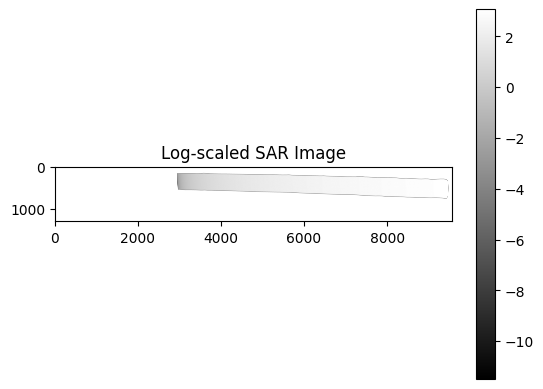

In [2]:
import numpy as np

# Log scaling (VERY important for SAR)
data_log = np.log1p(data)

plt.imshow(data_log, cmap='gray')
plt.colorbar()
plt.title("Log-scaled SAR Image")
plt.show()

In [3]:
with rasterio.open(file_path) as src:
    print(src.profile)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.4028226550889045e+38, 'width': 9554, 'height': 1305, 'count': 8, 'crs': CRS.from_wkt('PROJCS["OBLIQUE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["custom_proj4"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=ob_tran +R=1737400 +o_proj=eqc +o_lon_p=-95.0819785991905 +o_lat_p=176.134105315487 +lon_0=49.2508328804606 +wktext +no_defs"]]'), 'transform': Affine(100.0, 0.0, -479050.0,
       0.0, -100.0, 41150.0), 'blockxsize': 9554, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}


In [4]:
import numpy as np

print("Min:", np.min(data))
print("Max:", np.max(data))

Min: -1e+32
Max: 20.44283


In [5]:
data = data.astype(float)

# Replace extreme values with NaN
data[data < -1e20] = np.nan
data[data > 1e20] = np.nan

In [6]:
# Remove NaNs for stats
valid = data[~np.isnan(data)]

# Normalize
data_norm = (data - np.nanmin(valid)) / (np.nanmax(valid) - np.nanmin(valid))

In [7]:
data_log = np.log1p(data_norm)

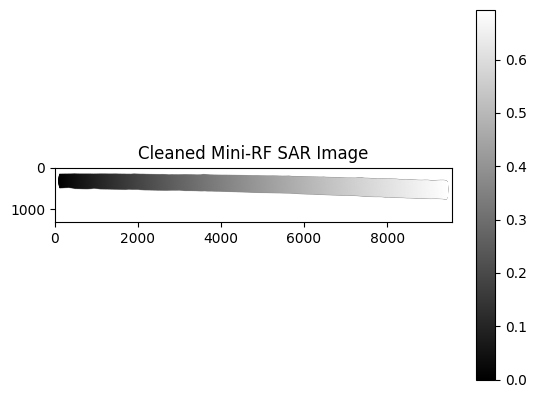

In [8]:
import matplotlib.pyplot as plt

plt.imshow(data_log, cmap='gray')
plt.colorbar()
plt.title("Cleaned Mini-RF SAR Image")
plt.show()

In [9]:
import numpy as np

# Mask invalid values
data[data < -1e20] = np.nan
data[data > 1e20] = np.nan

# Crop to valid region
rows = np.any(~np.isnan(data), axis=1)
cols = np.any(~np.isnan(data), axis=0)

cropped = data[rows][:, cols]

C:\Users\karna\AppData\Local\Temp\ipykernel_22316\661276448.py:3: RuntimeWarning: invalid value encountered in log1p
  plt.imshow(np.log1p(cropped), cmap='gray')


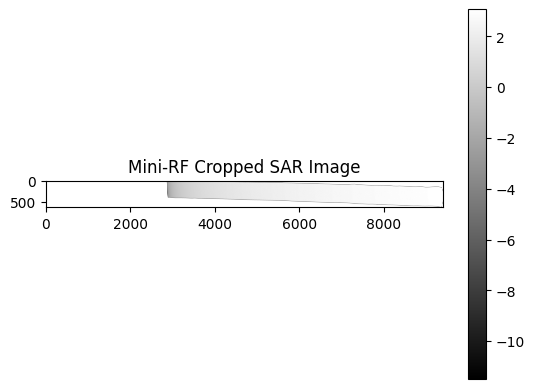

In [10]:
import matplotlib.pyplot as plt

plt.imshow(np.log1p(cropped), cmap='gray')
plt.colorbar()
plt.title("Mini-RF Cropped SAR Image")
plt.show()

In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_path = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"

with rasterio.open(file_path) as src:
    data = src.read(1)

# Convert to float
data = data.astype(float)

# Remove extreme invalid values
data[data < -1e20] = np.nan
data[data > 1e20] = np.nan

# Crop to valid SAR region
rows = np.any(~np.isnan(data), axis=1)
cols = np.any(~np.isnan(data), axis=0)
cropped = data[rows][:, cols]

print("Cropped shape:", cropped.shape)

Cropped shape: (624, 9392)


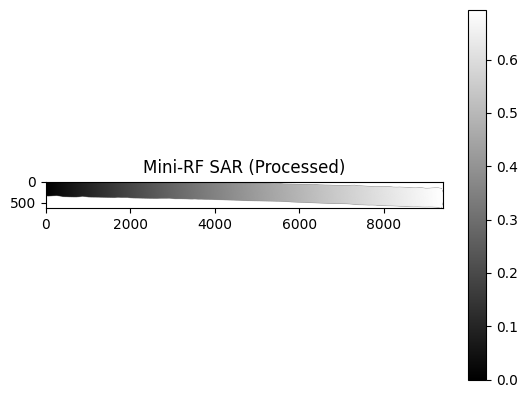

In [12]:
# Normalize
valid = cropped[~np.isnan(cropped)]
norm = (cropped - np.nanmin(valid)) / (np.nanmax(valid) - np.nanmin(valid))

# Log scaling (SAR standard)
log_img = np.log1p(norm)

plt.imshow(log_img, cmap='gray')
plt.colorbar()
plt.title("Mini-RF SAR (Processed)")
plt.show()

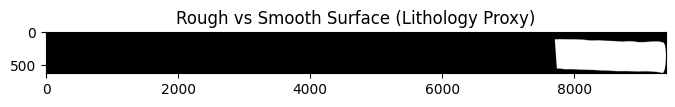

In [13]:
# Simple classification
rough = log_img > 0.6
smooth = log_img <= 0.6

plt.figure(figsize=(8,5))
plt.imshow(rough, cmap='gray')
plt.title("Rough vs Smooth Surface (Lithology Proxy)")
plt.show()

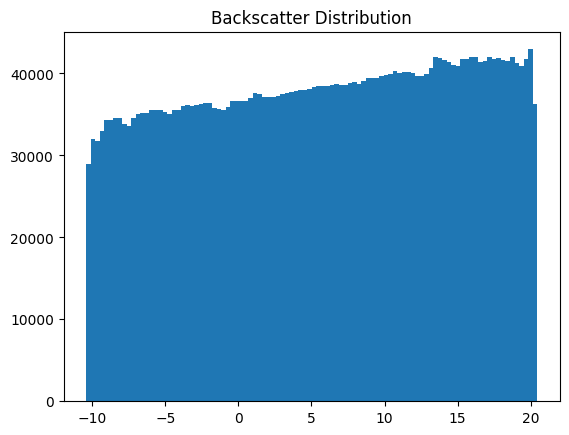

In [14]:
plt.hist(valid, bins=100)
plt.title("Backscatter Distribution")
plt.show()

In [16]:
import numpy as np
from scipy.ndimage import uniform_filter

def lee_filter(img, size=7):
    img = img.astype(np.float64)
    # local mean
    mean = uniform_filter(img, (size, size))
    # local variance
    mean_sq = uniform_filter(img*img, (size, size))
    var = mean_sq - mean*mean
    # overall variance (robust)
    overall_variance = np.nanmean(var)
    # weight
    w = var / (var + overall_variance)
    return mean + w * (img - mean)

In [19]:
import numpy as np

# Convert to float
data = data.astype(float)

# Remove only extreme values safely
data[data == 0] = np.nan   # optional (if lots of zeros)
data[np.isinf(data)] = np.nan

# Check BEFORE continuing
print("Valid count:", np.sum(~np.isnan(data)))
print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))

Valid count: 3803462
Min: -10.426156044006348
Max: 20.442829132080078


Valid pixels: 12467970


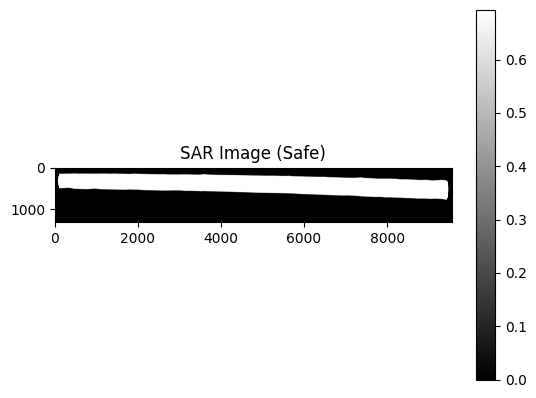

In [21]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

# Load
file_path = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"

with rasterio.open(file_path) as src:
    data = src.read(1)

# Clean
data = data.astype(float)
data[np.isinf(data)] = np.nan

print("Valid pixels:", np.sum(~np.isnan(data)))

# Normalize safely
valid = data[~np.isnan(data)]

data_norm = (data - np.nanmin(valid)) / (np.nanmax(valid) - np.nanmin(valid))
log_img = np.log1p(data_norm)

# Plot
plt.imshow(log_img, cmap='gray')
plt.title("SAR Image (Safe)")
plt.colorbar()
plt.show()

In [22]:
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_closing, binary_opening

valid = log_img[~np.isnan(log_img)]
th = threshold_otsu(valid)
mask = (log_img >= th)

# morphological cleanup
mask = binary_opening(mask, structure=np.ones((3,3)))
mask = binary_closing(mask, structure=np.ones((7,7)))

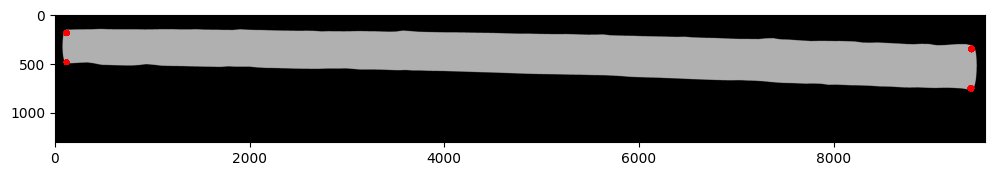

In [24]:
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.draw import circle_perimeter
import cv2  # optional; either use skimage or OpenCV

edges = canny(log_img, sigma=2)
hough_radii = np.arange(10, 120, 2)  # tune radii
hough_res = hough_circle(edges, hough_radii)
accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=30)

# draw on an RGB image
import matplotlib.pyplot as plt
img_rgb = np.dstack([log_img, log_img, log_img])
fig, ax = plt.subplots(1,1, figsize=(12,5))
ax.imshow(img_rgb, cmap='gray')
for center_y, center_x, radius in zip(cy, cx, radii):
    circy, circx = circle_perimeter(center_y, center_x, radius)
    ax.plot(circx, circy, color='red', linewidth=1)
plt.show()

In [2]:
import rasterio
import numpy as np

path = "F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"

with rasterio.open(path) as src:
    img = src.read(1)

print(img.shape)

(1305, 9554)


In [3]:
img = img[::4, ::4]   # downsample

In [4]:
from skimage.util import img_as_ubyte

img = (img - np.min(img)) / (np.max(img) - np.min(img))
img = img_as_ubyte(img)

In [5]:
from skimage.feature import graycomatrix, graycoprops

patch_size = 32

features = []

for i in range(0, img.shape[0], patch_size):
    for j in range(0, img.shape[1], patch_size):
        
        patch = img[i:i+patch_size, j:j+patch_size]

        if patch.shape != (patch_size, patch_size):
            continue

        glcm = graycomatrix(patch,
                            distances=[1],
                            angles=[0],
                            levels=256,
                            symmetric=True,
                            normed=True)

        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        # entropy
        p = glcm[:, :, 0, 0]
        p = p[p > 0]
        entropy = -np.sum(p * np.log(p))

        features.append([contrast, homogeneity, correlation, entropy])

In [6]:
import pandas as pd

df_moon = pd.DataFrame(features, columns=[
    "contrast", "homogeneity", "correlation", "entropy"
])

print(df_moon.head())

   contrast  homogeneity  correlation  entropy
0       0.0          1.0          1.0     -0.0
1       0.0          1.0          1.0     -0.0
2       0.0          1.0          1.0     -0.0
3       0.0          1.0          1.0     -0.0
4       0.0          1.0          1.0     -0.0


In [7]:
df_moon["domain"] = 1

orig shape, min, max, mean, std: (1305, 9554) -1.0000000331813535e+32 20.442829132080078 -6.9494138079415515e+31 4.604322763590333e+31
downsampled shape, min, max, mean, std: (327, 2389) -1.0000000331813535e+32 20.441282272338867 -6.956297121640298e+31 4.60140238188918e+31
unique values (sample of first 20): [-1.00000003e+32 -1.04249058e+01 -1.04239998e+01 -1.04230928e+01
 -1.04221859e+01 -1.04212780e+01 -1.04203701e+01 -1.04194613e+01
 -1.04189739e+01 -1.04185514e+01 -1.04180727e+01 -1.04176416e+01
 -1.04171705e+01 -1.04167309e+01 -1.04162674e+01 -1.04158201e+01
 -1.04153643e+01 -1.04149084e+01 -1.04144602e+01 -1.04139957e+01] count unique: 237197


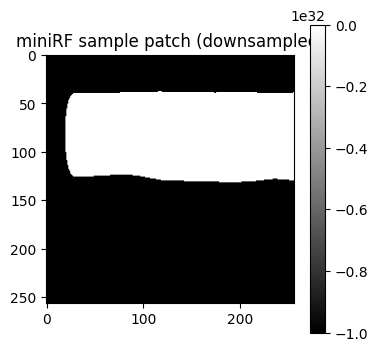

In [9]:
import rasterio, numpy as np
from skimage.util import img_as_ubyte
from matplotlib import pyplot as plt

path = "F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"   # <-- set this
with rasterio.open(path) as src:
    img_full = src.read(1).astype(float)

print("orig shape, min, max, mean, std:", img_full.shape, np.nanmin(img_full), np.nanmax(img_full),
      np.nanmean(img_full), np.nanstd(img_full))

# small downsample to be fast but preserve variation
img = img_full[::4, ::4]

print("downsampled shape, min, max, mean, std:", img.shape, np.nanmin(img), np.nanmax(img),
      np.nanmean(img), np.nanstd(img))

# quick histogram check
vals = img.flatten()
vals = vals[np.isfinite(vals)]
print("unique values (sample of first 20):", np.unique(vals)[:20], "count unique:", len(np.unique(vals)))

# show a small patch image so you can visually inspect
plt.figure(figsize=(4,4))
plt.imshow(img[:256,:256], cmap='gray')
plt.title('miniRF sample patch (downsampled)')
plt.colorbar()
plt.show()

In [12]:
# robust_glcm_miniRF.py
import rasterio, numpy as np, pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage.exposure import rescale_intensity, equalize_adapthist
from skimage.util import img_as_ubyte

def get_patch(img, i, j, size):
    return img[i:i+size, j:j+size]

def quantize_patch(patch, n_levels=64):
    # avoid global 0/255 by rescaling patch to its own min-max,
    # then map to [0, n_levels-1]
    if np.nanmax(patch) == np.nanmin(patch):
        return None  # constant patch
    p = rescale_intensity(patch, in_range='image', out_range=(0, n_levels-1))
    return p.astype(np.uint8)

def compute_glcm_features_for_patch(patch_uint8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=64):
    # graycomatrix expects values in [0, levels-1]
    glcm = graycomatrix(patch_uint8, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    props = {}
    for prop in ['contrast','dissimilarity','homogeneity','energy','correlation']:
        val = graycoprops(glcm, prop).mean()
        props[prop] = float(val)
    # entropy manually averaged over angles/distances
    p = glcm.mean(axis=(2,3))  # average over distances/angles
    p_flat = p.flatten()
    p_flat = p_flat[p_flat>0]
    props['entropy'] = float(-np.sum(p_flat * np.log(p_flat)))
    return props

def extract_patch_features(path_tif, patch_size=64, stride=None, n_levels=64, max_patches=None):
    if stride is None:
        stride = patch_size
    with rasterio.open(path_tif) as src:
        arr = src.read(1).astype(float)
    # optional; crop to multiple of patch_size for simplicity
    H, W = arr.shape
    Hc = (H // patch_size) * patch_size
    Wc = (W // patch_size) * patch_size
    arr = arr[:Hc, :Wc]
    features = []
    coords = []
    count = 0
    for i in range(0, Hc, stride):
        for j in range(0, Wc, stride):
            patch = get_patch(arr, i, j, patch_size)
            if patch.shape != (patch_size, patch_size):
                continue
            # small CLAHE (optional) to enhance texture
            try:
                patch_eq = equalize_adapthist(patch, clip_limit=0.01)
            except Exception:
                patch_eq = patch
            q = quantize_patch(patch_eq, n_levels=n_levels)
            if q is None:
                continue
            props = compute_glcm_features_for_patch(q, distances=[1,2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=n_levels)
            features.append(props)
            coords.append((i,j))
            count += 1
            if max_patches and count >= max_patches:
                break
        if max_patches and count >= max_patches:
            break
    df = pd.DataFrame(features)
    df['row'] = [c[0] for c in coords]
    df['col'] = [c[1] for c in coords]
    return df

# USAGE (lightweight):
#df_moon = extract_patch_features("minirf.tif", patch_size=64, stride=64, n_levels=64, max_patches=1000)
df_moon.to_csv("moon_glcm_patches.csv", index=False)

In [14]:
from skimage.feature import graycomatrix, graycoprops
from skimage.util import img_as_ubyte
import rasterio, numpy as np
with rasterio.open("F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif") as s:
    a = s.read(1)[::4, ::4]   # light downsample
a = (a - a.min()) / (a.max()-a.min())
patch = img_as_ubyte(a[:256,:256])
glcm = graycomatrix(patch, [1,2], [0,np.pi/4,np.pi/2,3*np.pi/4], levels=256, symmetric=True, normed=True)
print("contrast", graycoprops(glcm,'contrast').mean(), "homog", graycoprops(glcm,'homogeneity').mean())

contrast 487.59354238435037 homog 0.9925015602622898


orig shape, min, max, mean, std: (1305, 9554) -1.0000000331813535e+32 20.442829132080078 -6.9494138079415515e+31 4.604322763590333e+31
clipped to percentiles: -10.030183582305908 20.121580448150635
cleaned small tif written: minirf_clean_small.tif


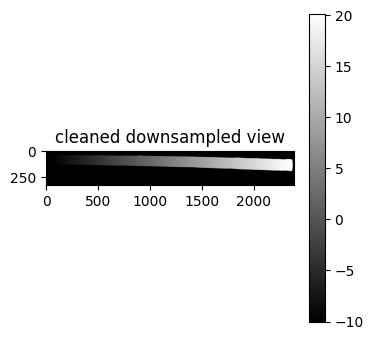

patch count: 1064
                count         mean          std         min          25%  \
contrast       1064.0    15.366239    23.163455    1.052334     1.060051   
dissimilarity  1064.0     0.847126     0.081233    0.048854     0.842435   
homogeneity    1064.0     0.710422     0.171742    0.594432     0.600229   
energy         1064.0     0.286055     0.308850    0.086326     0.092762   
correlation    1064.0     0.974725     0.080861    0.190078     0.971298   
entropy        1064.0     4.146569     2.136907    0.008958     1.255836   
row            1064.0   387.248120   152.193490  128.000000   256.000000   
col            1064.0  4981.413534  2697.237998  128.000000  2624.000000   

                       50%          75%          max  
contrast          1.061689    49.007161    72.183972  
dissimilarity     0.843191     0.870348     1.145777  
homogeneity       0.600630     0.978472     0.999184  
energy            0.092884     0.585270     0.999059  
correlation       0.99

In [16]:
# moon_glcm_clean_and_extract.py
import rasterio
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage.exposure import rescale_intensity, equalize_adapthist
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt

MINIRF_TIF = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"  # <<--- set this
OUT_CLEAN_TIF = "minirf_clean_small.tif"
PATCH_SIZE = 64        # try 64; increase to 128 if texture is coarse
STRIDE = 64
N_LEVELS = 64
MAX_PATCHES = 1200     # cap to keep laptop happy; set None to process all

def read_and_mask(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float64)
        meta = src.meta.copy()
        nodata = src.nodatavals[0] if src.nodatavals else None
    # If nodata not set, detect extreme sentinel values heuristically
    if nodata is None:
        # treat values with absolute > 1e20 as nodata
        nodata_mask = np.abs(arr) > 1e20
    else:
        nodata_mask = (arr == nodata)
    arr[nodata_mask] = np.nan
    return arr, meta

def percentile_clip(arr, pmin=2, pmax=98):
    valid = arr[np.isfinite(arr) & (arr > -1e10)]
    if valid.size == 0:
        raise ValueError("No finite pixels found")
    lo, hi = np.percentile(valid, [pmin, pmax])
    arr_clipped = np.clip(arr, lo, hi)
    return arr_clipped, lo, hi

def save_small_tif(ref_meta, arr, outpath):
    meta = ref_meta.copy()
    meta.update(dtype='float32', count=1, compress='lzw')
    with rasterio.open(outpath, 'w', **meta) as dst:
        dst.write(np.nan_to_num(arr).astype('float32'), 1)

def quantize_patch(patch, n_levels=N_LEVELS):
    # skip if contains nan
    if not np.isfinite(patch).all():
        return None
    if np.nanmax(patch) == np.nanmin(patch):
        return None
    # local stretch to [0, n_levels-1]
    p = rescale_intensity(patch, in_range='image', out_range=(0, n_levels-1))
    return p.astype(np.uint8)

def compute_glcm_props(patch_uint8):
    # returns averaged props across angles/distances
    glcm = graycomatrix(patch_uint8, distances=[1,2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=N_LEVELS, symmetric=True, normed=True)
    props = {}
    for prop in ['contrast','dissimilarity','homogeneity','energy','correlation']:
        props[prop] = float(graycoprops(glcm, prop).mean())
    # entropy (manual)
    p = glcm.mean(axis=(2,3))
    p_flat = p.flatten()
    p_flat = p_flat[p_flat > 0]
    props['entropy'] = float(-np.sum(p_flat * np.log(p_flat)))
    return props

def extract_patch_features(arr, patch_size=PATCH_SIZE, stride=STRIDE, n_levels=N_LEVELS, max_patches=MAX_PATCHES):
    H, W = arr.shape
    Hc = (H // patch_size) * patch_size
    Wc = (W // patch_size) * patch_size
    arr = arr[:Hc, :Wc]

    features = []
    coords = []
    count = 0
    for i in range(0, Hc, stride):
        for j in range(0, Wc, stride):
            patch = arr[i:i+patch_size, j:j+patch_size]
            # optionally enhance local contrast lightly
            try:
                patch_eq = equalize_adapthist(patch, clip_limit=0.01)
            except Exception:
                patch_eq = patch
            q = quantize_patch(patch_eq, n_levels=n_levels)
            if q is None:
                continue
            props = compute_glcm_props(q)
            features.append(props)
            coords.append((i,j))
            count += 1
            if max_patches and count >= max_patches:
                break
        if max_patches and count >= max_patches:
            break

    df = pd.DataFrame(features)
    df['row'] = [c[0] for c in coords]
    df['col'] = [c[1] for c in coords]
    return df

if __name__ == "__main__":
    arr, meta = read_and_mask(MINIRF_TIF)
    print("orig shape, min, max, mean, std:",
          arr.shape, np.nanmin(arr), np.nanmax(arr), np.nanmean(arr), np.nanstd(arr))

    arr_clipped, lo, hi = percentile_clip(arr, pmin=1, pmax=99)
    print("clipped to percentiles:", lo, hi)
    save_small_tif(meta, arr_clipped, OUT_CLEAN_TIF)
    print("cleaned small tif written:", OUT_CLEAN_TIF)

    # small diagnostic plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(4,4))
    plt.imshow(np.nan_to_num(arr_clipped)[::4, ::4], cmap='gray')
    plt.title('cleaned downsampled view')
    plt.colorbar()
    plt.show()

    # extract GLCM patch features (caps for laptop)
    df = extract_patch_features(arr_clipped, patch_size=PATCH_SIZE, stride=STRIDE, n_levels=N_LEVELS, max_patches=MAX_PATCHES)
    print("patch count:", len(df))
    print(df.describe().T)
    df.to_csv("moon_glcm_patches.csv", index=False)
    print("patch features saved to moon_glcm_patches.csv")

In [4]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling

# -----------------------------
# PATHS
# -----------------------------
paths = {
    "contrast": r"G:\Satellite Data & Analysis\Lithological survey\subset_S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_CONTRAST.tif",
    "homogeneity": r"G:\Satellite Data & Analysis\Lithological survey\subset_S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_HOM.tif",
    "entropy": r"F:\SATELLITE ANALYSIS\Result_LT\subset_0_of_subset_0_of_S1A_IW_GRDH_20250105Orb_tnr_Cal_glcm_Spk_TC_VH_Entropy.tif",
}

STEP = 8

# -----------------------------
# READ + RESAMPLE TO SAME GRID
# -----------------------------

# Use first raster as reference
ref_path = list(paths.values())[0]

with rasterio.open(ref_path) as ref:
    ref_h = ref.height // STEP
    ref_w = ref.width // STEP
    transform = ref.transform

arrays = {}

for name, path in paths.items():
    if not os.path.exists(path):
        print(f"Missing: {name}")
        continue

    with rasterio.open(path) as src:
        arr = src.read(
            1,
            out_shape=(ref_h, ref_w),
            resampling=Resampling.bilinear
        ).astype(np.float32)

        nodata = src.nodata

    # -----------------------------
    # CLEAN NODATA
    # -----------------------------
    arr[arr == nodata] = np.nan
    arr[arr == -9999] = np.nan
    arr[arr == -1] = np.nan
    arr[np.abs(arr) > 1e20] = np.nan

    arrays[name] = arr
    print(f"{name} aligned shape:", arr.shape)

# -----------------------------
# STACK FEATURES
# -----------------------------

stack = np.stack([arrays[k] for k in arrays], axis=-1)

# keep only valid pixels
mask = np.all(np.isfinite(stack), axis=2)

valid_pixels = stack[mask]

df_earth = pd.DataFrame(valid_pixels, columns=list(arrays.keys()))

print("\nClean Earth dataset:", df_earth.shape)
print(df_earth.head())

# -----------------------------
# SAVE
# -----------------------------
df_earth.to_csv("earth_features_clean.csv", index=False)
print("\n✅ Saved: earth_features_clean.csv")

contrast aligned shape: (799, 1168)
homogeneity aligned shape: (799, 1168)
entropy aligned shape: (799, 1168)

Clean Earth dataset: (586908, 3)
    contrast  homogeneity      entropy
0  26.588926     0.334153 -8061.179688
1  24.628227     0.432812 -5537.710938
2  45.241005     0.457289 -7609.824707
3  57.645214     0.343773 -9065.112305
4  26.007544     0.326766 -9808.815430

✅ Saved: earth_features_clean.csv


In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

# -----------------------------
# LOAD MODEL
# -----------------------------
rf = joblib.load("rf_earth_model.pkl")

print("Model loaded")

# -----------------------------
# LOAD ORIGINAL MOON CSV
# -----------------------------
df = pd.read_csv("moon_glcm_from_tiff.csv")

print("Original data shape:", df.shape)

# -----------------------------
# CLEAN
# -----------------------------
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# -----------------------------
# 🔥 CHECK BEFORE NORMALIZATION
# -----------------------------
print("\nBefore normalization:")
print(df["contrast"].describe())

# -----------------------------
# 🔥 APPLY NORMALIZATION
# -----------------------------
df["contrast"] = df["contrast"] / df["contrast"].max()
df["entropy"] = df["entropy"] / df["entropy"].max()

# -----------------------------
# 🔥 CHECK AFTER NORMALIZATION
# -----------------------------
print("\nAfter normalization:")
print(df["contrast"].describe())

# -----------------------------
# FEATURES
# -----------------------------
X = df[["contrast", "entropy"]].values

# -----------------------------
# DOMAIN ADAPTATION
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# MATCH EARTH MODEL INPUT
# -----------------------------
X_final = np.column_stack([
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 0],
    X_scaled[:, 1]
])

# -----------------------------
# PREDICT
# -----------------------------
df["class"] = rf.predict(X_final)

# -----------------------------
# SAVE NEW FILE (NEW NAME)
# -----------------------------
df.to_csv("moon_FIXED_NEW.csv", index=False)

print("\nSaved: moon_FIXED_NEW.csv")

# -----------------------------
# CHECK OUTPUT
# -----------------------------
print("\nClass counts:")
print(df["class"].value_counts())

Model loaded
Original data shape: (15433, 4)

Before normalization:
count    15433.000000
mean        12.152355
std        179.287318
min          0.000000
25%          0.000000
50%          0.000000
75%          0.066667
max       4303.191667
Name: contrast, dtype: float64

After normalization:
count    15433.000000
mean         0.002824
std          0.041664
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000015
max          1.000000
Name: contrast, dtype: float64

Saved: moon_FIXED_NEW.csv

Class counts:
class
3    15025
1      166
2      145
0       97
Name: count, dtype: int64


Dataset: (15433, 5)

Class Distribution:
class
0       97
1      166
2      145
3    15025
Name: count, dtype: int64


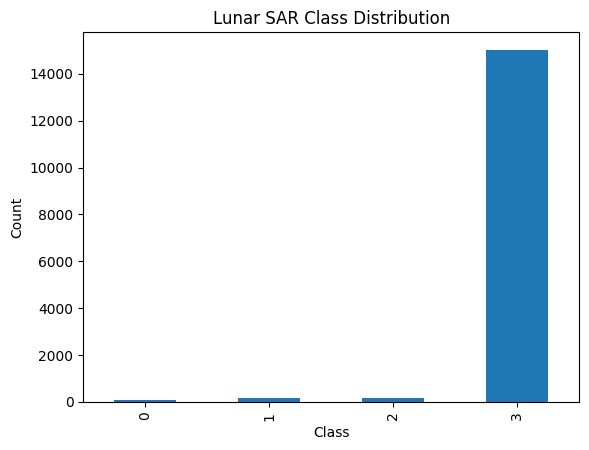

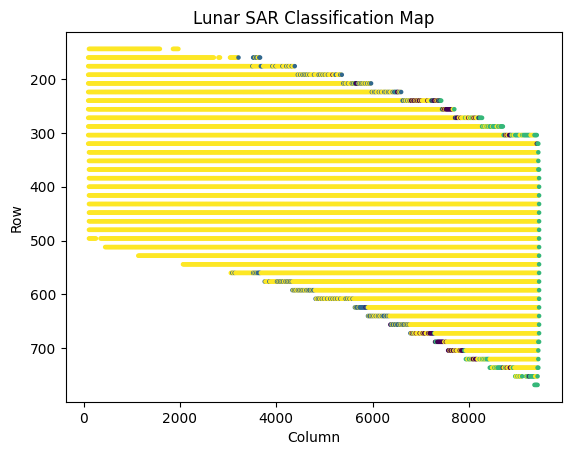


Feature Summary:
       contrast   entropy
class                    
0      0.042674  0.547944
1      0.020175  0.471298
2      0.244700  0.468133
3      0.000041  0.233884

✅ SAR FINALIZED


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# LOAD FINAL DATA
# -----------------------------
df = pd.read_csv("moon_FIXED_NEW.csv")

print("Dataset:", df.shape)

# -----------------------------
# CLASS DISTRIBUTION
# -----------------------------
counts = df["class"].value_counts().sort_index()

print("\nClass Distribution:")
print(counts)

# -----------------------------
# SAVE COUNTS
# -----------------------------
counts.to_csv("final_class_counts.csv")

# -----------------------------
# BAR PLOT
# -----------------------------
plt.figure()
counts.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Lunar SAR Class Distribution")
plt.savefig("class_distribution.png")
plt.show()

# -----------------------------
# SPATIAL MAP
# -----------------------------
plt.figure()
plt.scatter(df["col"], df["row"], c=df["class"], s=5)
plt.gca().invert_yaxis()
plt.title("Lunar SAR Classification Map")
plt.xlabel("Column")
plt.ylabel("Row")
plt.savefig("lunar_map.png")
plt.show()

# -----------------------------
# FEATURE SUMMARY
# -----------------------------
summary = df.groupby("class")[["contrast", "entropy"]].mean()

print("\nFeature Summary:")
print(summary)

summary.to_csv("feature_summary.csv")

print("\n✅ SAR FINALIZED")

In [3]:
import rasterio
import pandas as pd

with rasterio.open("F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VV_Entropy.tif") as src:
    transform = src.transform
    height, width = src.shape

rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

xs, ys = rasterio.transform.xy(transform, rows, cols)

df['x'] = np.array(xs).flatten()
df['y'] = np.array(ys).flatten()

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


MemoryError: Unable to allocate 3.63 GiB for an array with shape (3, 162429190) and data type float64

CRS: EPSG:4326

Loading VV_contrast...
VV_contrast shape: (555, 1141)
VV_contrast valid pixels: 633255

Loading VV_entropy...
VV_entropy shape: (555, 1141)
VV_entropy valid pixels: 633255

Loading VH_contrast...
VH_contrast shape: (555, 1141)
VH_contrast valid pixels: 633255

Loading VH_entropy...
VH_entropy shape: (555, 1141)
VH_entropy valid pixels: 633255

Total valid pixels after cleaning: (633255, 4)
Already in EPSG:4326
Sampling data...

Final dataset: (200000, 6)
   VV_contrast  VV_entropy  VH_contrast  VH_entropy       lon       lat
0          0.0        0.00         77.0        3.48  0.100429 -0.040454
1         60.0        4.50          0.0        0.28  0.107603 -0.012532
2         23.0        1.58        255.0        5.10  0.080413 -0.006303
3         94.0        4.70          2.0        1.28  0.122181 -0.033492
4         17.0        2.22        219.0        5.08  0.073124 -0.034884

✅ DONE — Saved earth_VV_VH_features_WITH_COORDS.csv


In [6]:
print("Lon range:", lons.min(), lons.max())
print("Lat range:", lats.min(), lats.max())

Lon range: 0.0 0.13190023823796082
Lat range: -0.04060023568099069 0.0


In [9]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import transform
from affine import Affine

# -----------------------------
# PATHS (EDIT IF NEEDED)
# -----------------------------

paths = {
    "VV_contrast": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VV_Contrast.tif",
    "VV_entropy": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VH_Entropy.tif",
    "VH_contrast": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VH_Contrast.tif",
    "VH_entropy": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VH_Entropy.tif",
}

# -----------------------------
# MEMORY CONTROL
# -----------------------------

STEP = 16
MAX_SAMPLES = 200000

# -----------------------------
# REFERENCE GRID + TRANSFORM FIX
# -----------------------------

ref_path = list(paths.values())[0]

with rasterio.open(ref_path) as ref:
    ref_h_full = ref.height
    ref_w_full = ref.width
    ref_transform = ref.transform
    ref_crs = ref.crs

# Downsampled size
ref_h = ref_h_full // STEP
ref_w = ref_w_full // STEP

# Scale transform (VERY IMPORTANT)
scale_x = ref_w_full / ref_w
scale_y = ref_h_full / ref_h

new_transform = ref_transform * Affine.scale(scale_x, scale_y)

print("CRS:", ref_crs)

arrays = {}

# -----------------------------
# LOAD + CLEAN
# -----------------------------

for name, path in paths.items():

    print(f"\nLoading {name}...")

    with rasterio.open(path) as src:
        arr = src.read(
            1,
            out_shape=(ref_h, ref_w),
            resampling=Resampling.nearest
        ).astype(np.float32)

        nodata = src.nodata

    # CLEANING
    if nodata is not None:
        arr[arr == nodata] = np.nan

    arr[arr == -9999] = np.nan
    arr[arr == -1] = np.nan
    arr[np.abs(arr) > 1e20] = np.nan

    if "contrast" in name:
        arr[arr < 0] = np.nan

    if "entropy" in name:
        arr[arr < 0] = np.nan

    arrays[name] = arr

    print(f"{name} shape:", arr.shape)
    print(f"{name} valid pixels:", np.sum(np.isfinite(arr)))

# -----------------------------
# STACK FEATURES
# -----------------------------

features = list(arrays.keys())
stack = np.stack([arrays[f] for f in features], axis=-1)

# VALID MASK
mask = np.all(np.isfinite(stack), axis=2)

rows, cols = np.where(mask)
valid_pixels = stack[rows, cols]

print("\nTotal valid pixels after cleaning:", valid_pixels.shape)

# -----------------------------
# PIXEL → GEO COORDINATES (FIXED)
# -----------------------------

# Vectorized (fast)
xs, ys = new_transform * (cols, rows)

# -----------------------------
# CONVERT TO LAT/LON (if needed)
# -----------------------------

if ref_crs is not None and ref_crs.to_string() != "EPSG:4326":
    print("Converting to EPSG:4326 (lat/lon)...")

    lon_list, lat_list = transform(
        ref_crs,
        "EPSG:4326",
        xs.tolist(),
        ys.tolist()
    )

    lons = np.array(lon_list)
    lats = np.array(lat_list)

else:
    print("Already in EPSG:4326")

    lons = xs
    lats = ys

# -----------------------------
# SAMPLING
# -----------------------------

if valid_pixels.shape[0] > MAX_SAMPLES:
    print("Sampling data...")

    idx = np.random.choice(valid_pixels.shape[0], MAX_SAMPLES, replace=False)

    valid_pixels = valid_pixels[idx]
    lons = lons[idx]
    lats = lats[idx]

# -----------------------------
# CREATE DATAFRAME
# -----------------------------

df = pd.DataFrame(valid_pixels, columns=features)

df["lon"] = lons
df["lat"] = lats

# -----------------------------
# NORMALIZATION
# -----------------------------

df["VV_entropy"] = df["VV_entropy"] / 50.0
df["VH_entropy"] = df["VH_entropy"] / 50.0

# -----------------------------
# FINAL CLEAN
# -----------------------------

df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("\nFinal dataset:", df.shape)
print(df.head())

# -----------------------------
# SAVE
# -----------------------------

output_path = "earth_VV_VH_features_WITH_COORDS.csv"
df.to_csv(output_path, index=False)

print(f"\n✅ DONE — Saved {output_path}")

CRS: EPSG:4326

Loading VV_contrast...
VV_contrast shape: (555, 1141)
VV_contrast valid pixels: 633255

Loading VV_entropy...
VV_entropy shape: (555, 1141)
VV_entropy valid pixels: 633255

Loading VH_contrast...
VH_contrast shape: (555, 1141)
VH_contrast valid pixels: 633255

Loading VH_entropy...
VH_entropy shape: (555, 1141)
VH_entropy valid pixels: 633255

Total valid pixels after cleaning: (633255, 4)
Already in EPSG:4326
Sampling data...

Final dataset: (200000, 6)
   VV_contrast  VV_entropy  VH_contrast  VH_entropy       lon       lat
0          1.0        4.64        216.0        4.64  0.272355 -0.016434
1        233.0        4.76        119.0        4.76  2.073230 -0.537642
2          7.0        3.08         61.0        3.08  1.458116 -0.539990
3        119.0        2.78         16.0        2.78  0.985664 -0.068086
4          0.0        5.06        185.0        5.06  0.138956 -0.008217

✅ DONE — Saved earth_VV_VH_features_WITH_COORDS.csv


In [10]:
with rasterio.open("G:\Satellite Data & Analysis\Lithological survey\RESULTS\subset_0_of_subset_0_of_S1A_IW_GRDH_20250105Orb_tnr_Cal_glcm_Spk_TC_kmeans_VV_Hom.tif") as src:
    cluster = src.read(1)
    transform = src.transform

In [11]:
print(src.crs)
print(src.bounds)

EPSG:4326
BoundingBox(left=69.44016477642252, bottom=23.74817196463661, right=70.07689064980644, top=24.039046453634512)


In [12]:
import numpy as np
import pandas as pd
import rasterio

# -----------------------------
# LOAD KMEANS TIFF
# -----------------------------

path = "G:\Satellite Data & Analysis\Lithological survey\RESULTS\subset_0_of_subset_0_of_S1A_IW_GRDH_20250105Orb_tnr_Cal_glcm_Spk_TC_kmeans_VV_Hom.tif"

with rasterio.open(path) as src:
    cluster = src.read(1)
    transform = src.transform
    crs = src.crs

print("CRS:", crs)

# -----------------------------
# REMOVE INVALID VALUES
# -----------------------------

mask = cluster >= 0  # adjust if needed

rows, cols = np.where(mask)
values = cluster[rows, cols]

# -----------------------------
# PIXEL → LAT/LON
# -----------------------------

xs, ys = transform * (cols, rows)

# -----------------------------
# CREATE DATAFRAME
# -----------------------------

df = pd.DataFrame({
    "cluster": values,
    "lon": xs,
    "lat": ys
})

print(df.head())
print("Total points:", df.shape)

CRS: EPSG:4326
   cluster        lon        lat
0      255  69.440165  24.039046
1      255  69.440255  24.039046
2      255  69.440344  24.039046
3      255  69.440434  24.039046
4      255  69.440524  24.039046
Total points: (22950944, 3)


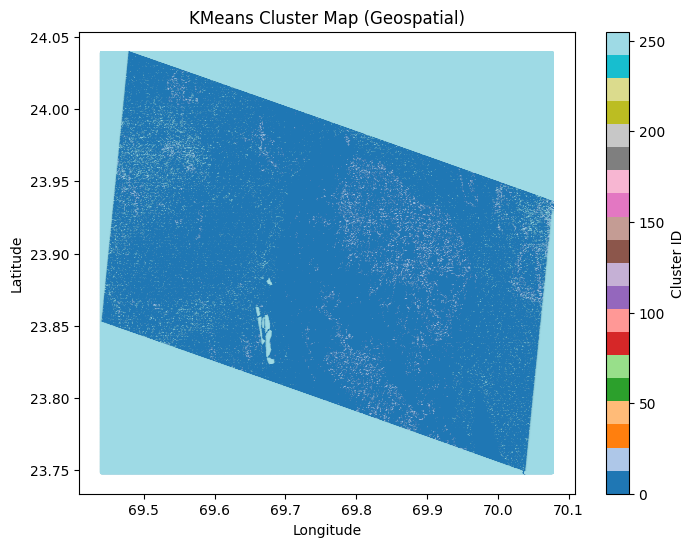

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["lon"], df["lat"], c=df["cluster"], s=1, cmap="tab20")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans Cluster Map (Geospatial)")

plt.colorbar(label="Cluster ID")
plt.show()

In [14]:
with rasterio.open("G:\Satellite Data & Analysis\Lithological survey\RESULTS\subset_0_of_subset_0_of_S1A_IW_GRDH_20250105Orb_tnr_Cal_glcm_Spk_TC_kmeans_VV_Hom.tif") as k, rasterio.open("F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VV_Entropy.tif") as g:
    print(k.shape, g.shape)
    print(k.transform == g.transform)

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


(3238, 7088) (8890, 18271)
False


In [15]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# -----------------------------
# FILE PATHS
# -----------------------------

kmeans_path = "G:\Satellite Data & Analysis\Lithological survey\RESULTS\subset_0_of_subset_0_of_S1A_IW_GRDH_20250105Orb_tnr_Cal_glcm_Spk_TC_kmeans_VV_Hom.tif"
glcm_path = "F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VV_Entropy.tif"
# glcm_path = "glcm_vv_contrast.tif"   # change as needed

# -----------------------------
# LOAD KMEANS (REFERENCE)
# -----------------------------

with rasterio.open(kmeans_path) as ref:
    ref_data = ref.read(1)
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = ref.shape

# -----------------------------
# LOAD GLCM
# -----------------------------

with rasterio.open(glcm_path) as src:
    glcm_data = src.read(1)
    src_transform = src.transform
    src_crs = src.crs

# -----------------------------
# CREATE EMPTY TARGET ARRAY
# -----------------------------

aligned_glcm = np.empty(ref_shape, dtype=np.float32)

# -----------------------------
# REPROJECT / RESAMPLE
# -----------------------------

reproject(
    source=glcm_data,
    destination=aligned_glcm,
    src_transform=src_transform,
    src_crs=src_crs,
    dst_transform=ref_transform,
    dst_crs=ref_crs,
    resampling=Resampling.bilinear
)

print("Aligned GLCM shape:", aligned_glcm.shape)

Aligned GLCM shape: (3238, 7088)


In [21]:
import numpy as np
import rasterio
import cv2

# -----------------------------
# PATHS
# -----------------------------

kmeans_path = r"G:\Satellite Data & Analysis\Lithological survey\RESULTS\subset_0_of_subset_0_of_S1A_IW_GRDH_20250105Orb_tnr_Cal_glcm_Spk_TC_kmeans_VV_Hom.tif"

glcm_paths = {
    "VV_contrast": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VV_Contrast.tif",
    "VV_entropy": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VV_Entropy.tif",
    "VH_contrast": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VH_Contrast.tif",
    "VH_entropy": r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VH_Entropy.tif",
}

# -----------------------------
# LOAD KMEANS (REFERENCE)
# -----------------------------

with rasterio.open(kmeans_path) as src:
    cluster = src.read(1)
    transform = src.transform

ref_shape = cluster.shape

print("KMeans shape:", ref_shape)

# -----------------------------
# ALIGN ALL GLCM
# -----------------------------

aligned_features = {}

for name, path in glcm_paths.items():

    print(f"\nProcessing {name}...")

    with rasterio.open(path) as src:
        glcm = src.read(1)

    # Resize to match KMeans
    aligned = cv2.resize(
        glcm,
        (ref_shape[1], ref_shape[0]),
        interpolation=cv2.INTER_LINEAR
    )

    aligned_features[name] = aligned

    print(f"{name} aligned shape:", aligned.shape)

KMeans shape: (3238, 7088)

Processing VV_contrast...


c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


VV_contrast aligned shape: (3238, 7088)

Processing VV_entropy...
VV_entropy aligned shape: (3238, 7088)

Processing VH_contrast...
VH_contrast aligned shape: (3238, 7088)

Processing VH_entropy...
VH_entropy aligned shape: (3238, 7088)


In [22]:
import numpy as np
import pandas as pd

# -----------------------------
# VALID MASK
# -----------------------------

mask = (cluster >= 0)

for arr in aligned_features.values():
    mask &= np.isfinite(arr)

rows, cols = np.where(mask)

print("Total pixels:", len(rows))

# -----------------------------
# 🔥 SAMPLING (VERY IMPORTANT)
# -----------------------------

MAX_SAMPLES = 200000

if len(rows) > MAX_SAMPLES:
    idx = np.random.choice(len(rows), MAX_SAMPLES, replace=False)
    rows = rows[idx]
    cols = cols[idx]

print("Using samples:", len(rows))

# -----------------------------
# EXTRACT DATA
# -----------------------------

data = {
    "cluster": cluster[rows, cols]
}

for name, arr in aligned_features.items():
    data[name] = arr[rows, cols]

# -----------------------------
# COORDINATES (NOW SAFE)
# -----------------------------

lons, lats = transform * (cols, rows)

data["lon"] = lons
data["lat"] = lats

# -----------------------------
# DATAFRAME
# -----------------------------

df = pd.DataFrame(data)

print(df.head())
print("Final dataset:", df.shape)

Total pixels: 22950944
Using samples: 200000
   cluster  VV_contrast  VV_entropy  VH_contrast  VH_entropy        lon  \
0        1          221         255           56         203  69.493525   
1      255          180         242            4          90  70.055511   
2      255           77          90          255         250  69.959391   
3        2          177         240           26         164  69.887705   
4      255            1          49           51         134  69.886987   

         lat  
0  23.848604  
1  23.896304  
2  23.971673  
3  23.951012  
4  23.761826  
Final dataset: (200000, 7)


In [23]:
cluster_stats = df.groupby("cluster").mean()
print(cluster_stats)

         VV_contrast  VV_entropy  VH_contrast  VH_entropy        lon  \
cluster                                                                
0          81.220133  165.797996    54.808378  131.481742  69.757932   
1          85.306959  169.047355    57.422622  138.133464  69.776934   
2          86.256456  166.359395    59.902773  142.216827  69.757546   
3          82.260555  156.740607    61.181666  147.506133  69.731855   
4          90.132701  167.067715    47.902521  133.819340  69.745649   
5          93.412370  171.735461    45.394962  131.243967  69.761450   
6          86.190712  161.682682    53.449277  140.636510  69.729586   
7          79.618064  152.654688    63.032907  148.173757  69.715068   
8          97.592773  176.838544    43.849506  127.497902  69.774268   
9          82.469215  155.743891    57.906758  144.729829  69.716688   
10         98.437837  179.853957    41.101151  125.477627  69.787309   
11        100.685936  182.842414    40.285714  123.711118  69.80

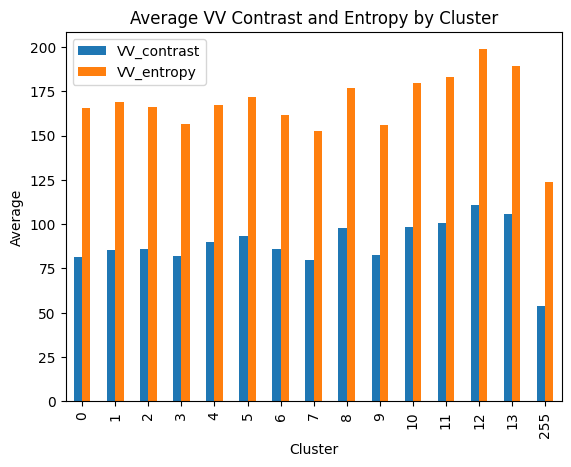

In [24]:
df.groupby("cluster")[["VV_contrast", "VV_entropy"]].mean().plot(kind="bar")
plt.title("Average VV Contrast and Entropy by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average")
plt.show()

In [25]:
df["VV_entropy"] /= 50
df["VH_entropy"] /= 50

In [26]:
df.groupby("cluster").mean()

,VV_contrast,VV_entropy,VH_contrast,VH_entropy,lon,lat
cluster,,,,,,
0,81.220133,3.315960,54.808378,2.629635,69.757932,23.897336
1,85.306959,3.380947,57.422622,2.762669,69.776934,23.886159
2,86.256456,3.327188,59.902773,2.844337,69.757546,23.892356
3,82.260555,3.134812,61.181666,2.950123,69.731855,23.893809
4,90.132701,3.341354,47.902521,2.676387,69.745649,23.893971
5,93.412370,3.434709,45.394962,2.624879,69.761450,23.893552
6,86.190712,3.233654,53.449277,2.812730,69.729586,23.892741
7,79.618064,3.053094,63.032907,2.963475,69.715068,23.890155
8,97.592773,3.536771,43.849506,2.549958,69.774268,23.892664


In [2]:
def label_cluster(c):
    if c in [0,1,4]:
        return "Smooth"
    elif c in [2,3,6,7,9]:
        return "Vegetation"
    elif c in [5,8]:
        return "Mixed"
    elif c in [10,11,12,13]:
        return "Rough"
    elif c == 255:
        return "Anomaly"
    else:
        return "Unknown"

df["terrain"] = df["cluster"].apply(label_cluster)

NameError: name 'df' is not defined

In [1]:
df.groupby("cluster").mean()

NameError: name 'df' is not defined

In [3]:
import rasterio

with rasterio.open("F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif") as src:
    print(src.crs)
    print(src.shape)
    print(src.count)

PROJCS["OBLIQUE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["custom_proj4"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=ob_tran +R=1737400 +o_proj=eqc +o_lon_p=-95.0819785991905 +o_lat_p=176.134105315487 +lon_0=49.2508328804606 +wktext +no_defs"]]
(1305, 9554)
8


In [7]:
import rasterio
import numpy as np

# -----------------------------
# LOAD IMAGE
# -----------------------------

path = "F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"   # 🔁 replace with your file

with rasterio.open(path) as src:
    img = src.read(1)          # ✅ NOW img is defined
    transform = src.transform
    crs = src.crs

print("Shape:", img.shape)
print("CRS:", crs)

Shape: (1305, 9554)
CRS: PROJCS["OBLIQUE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["custom_proj4"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=ob_tran +R=1737400 +o_proj=eqc +o_lon_p=-95.0819785991905 +o_lat_p=176.134105315487 +lon_0=49.2508328804606 +wktext +no_defs"]]


In [19]:
# -----------------------------
# CLEAN
# -----------------------------

img = np.nan_to_num(img)

# -----------------------------
# NORMALIZE (0–255)
# -----------------------------
p2, p98 = np.percentile(img, (2, 98))
img = np.clip(img, p2, p98)
img = (img - p2) / (p98 - p2)
img = (img * 255).astype(np.uint8)

In [9]:
STEP = 8   # increase to 16 if slow

img = img[::STEP, ::STEP]
print("Downsampled shape:", img.shape)

Downsampled shape: (164, 1195)


In [10]:
from skimage.feature import graycomatrix, graycoprops

window_size = 3   # small window = faster

h, w = img.shape

contrast_map = np.zeros((h, w), dtype=np.float32)
entropy_map = np.zeros((h, w), dtype=np.float32)

for i in range(window_size, h - window_size):
    for j in range(window_size, w - window_size):

        window = img[i-window_size:i+window_size,
                     j-window_size:j+window_size]

        glcm = graycomatrix(window,
                            distances=[1],
                            angles=[0],
                            levels=256,
                            symmetric=True,
                            normed=True)

        contrast = graycoprops(glcm, 'contrast')[0, 0]

        # entropy
        p = glcm + 1e-10
        entropy = -np.sum(p * np.log2(p))

        contrast_map[i, j] = contrast
        entropy_map[i, j] = entropy

In [11]:
stack = np.stack([contrast_map, entropy_map], axis=-1)

mask = np.all(np.isfinite(stack), axis=2)

rows, cols = np.where(mask)

pixels = stack[rows, cols]

In [12]:
pixels[:,1] /= 50.0

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(pixels)

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [16]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [17]:
# -----------------------------
# STACK FEATURES
# -----------------------------

stack = np.stack([contrast_map, entropy_map], axis=-1)

# -----------------------------
# REMOVE ZERO / INVALID PIXELS
# -----------------------------

mask = (
    (contrast_map > 0) & 
    (entropy_map > 0) &
    np.isfinite(contrast_map) &
    np.isfinite(entropy_map)
)

rows, cols = np.where(mask)

pixels = stack[rows, cols]

print("Valid pixels:", pixels.shape)

Valid pixels: (3213, 2)


In [18]:
print("Contrast range:", pixels[:,0].min(), pixels[:,0].max())
print("Entropy range:", pixels[:,1].min(), pixels[:,1].max())

Contrast range: 2167.5 13005.0
Entropy range: 0.24439333 1.7221458


In [14]:
lons, lats = transform * (cols * STEP, rows * STEP)

In [15]:
import pandas as pd

df_moon = pd.DataFrame({
    "cluster": labels,
    "contrast": pixels[:,0],
    "entropy": pixels[:,1],
    "lon": lons,
    "lat": lats
})

print(df_moon.head())

   cluster  contrast  entropy       lon      lat
0        0       0.0      0.0 -479050.0  41150.0
1        0       0.0      0.0 -478250.0  41150.0
2        0       0.0      0.0 -477450.0  41150.0
3        0       0.0      0.0 -476650.0  41150.0
4        0       0.0      0.0 -475850.0  41150.0


In [37]:
# =============================
# 🔧 FIX OPENMP WARNING
# =============================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =============================
# IMPORTS
# =============================
import rasterio
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from sklearn.cluster import KMeans
from tqdm import tqdm  # optional, for progress bar

# =============================
# PATH (EDIT THIS)
# =============================
path = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"

# =============================
# LOAD IMAGE
# =============================
with rasterio.open(path) as src:
    img = src.read(1)
    transform = src.transform
    crs = src.crs

print("Original shape:", img.shape)
print("CRS:", crs)

# =============================
# CLEAN IMAGE
# =============================
img = np.nan_to_num(img)

# =============================
# 🔥 ROBUST NORMALIZATION
# =============================
p2, p98 = np.percentile(img, (2, 98))
img = np.clip(img, p2, p98)
img = (img - p2) / (p98 - p2 + 1e-8)

# Quantize to 0–127 (uint8)
img = (img * 127).astype(np.uint8)

# =============================
# 🔥 DOWNSAMPLE
# =============================
STEP = 8
img = img[::STEP, ::STEP]
print("Downsampled shape:", img.shape)

# =============================
# GLCM SETTINGS
# =============================
window_size = 7
h, w = img.shape

contrast_map = np.zeros((h, w), dtype=np.float32)
entropy_map = np.zeros((h, w), dtype=np.float32)

print("Computing GLCM...")
# Use tqdm for progress if available
iterator = range(window_size, h - window_size)
if 'tqdm' in globals():
    iterator = tqdm(iterator, desc="Processing rows")

for i in iterator:
    for j in range(window_size, w - window_size):
        window = img[i - window_size : i + window_size,
                     j - window_size : j + window_size]

        glcm = graycomatrix(
            window,
            distances=[1],
            angles=[0],
            levels=128,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm, 'contrast')[0, 0]
        p = glcm / np.sum(glcm)
        entropy = -np.sum(p * np.log2(p + 1e-10))

        contrast_map[i, j] = contrast
        entropy_map[i, j] = entropy

print("GLCM done")

# =============================
# STACK FEATURES
# =============================
stack = np.stack([contrast_map, entropy_map], axis=-1)

# =============================
# FILTER VALID PIXELS
# =============================
mask = (contrast_map > 1) & (entropy_map > 0.01)
rows, cols = np.where(mask)
pixels = stack[rows, cols]

print("Valid pixels:", pixels.shape)

# =============================
# SAMPLING (optional)
# =============================
MAX_SAMPLES = 200000
if len(pixels) > MAX_SAMPLES:
    idx = np.random.choice(len(pixels), MAX_SAMPLES, replace=False)
    pixels = pixels[idx]
    rows = rows[idx]
    cols = cols[idx]

print("Using samples:", len(pixels))

# =============================
# CLUSTERING
# =============================
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(pixels)
# =============================
# CLUSTER-BASED TERRAIN LABELING
# =============================

cluster_stats = df_moon.groupby("cluster")[["contrast", "entropy"]].mean()

print("\nCluster stats:\n", cluster_stats)

# Sort clusters by contrast
sorted_clusters = cluster_stats.sort_values("contrast")

cluster_ids = sorted_clusters.index.tolist()

terrain_map = {}

# Lowest contrast → smooth (mare)
terrain_map[cluster_ids[0]] = "Mare (smooth)"
terrain_map[cluster_ids[1]] = "Mare (smooth)"

# Highest contrast → rough (highlands)
terrain_map[cluster_ids[-1]] = "Highlands (rough)"
terrain_map[cluster_ids[-2]] = "Highlands (rough)"

# Middle → transitional
for cid in cluster_ids[2:-2]:
    terrain_map[cid] = "Crater / Transitional"

# Apply
df_moon["terrain"] = df_moon["cluster"].map(terrain_map)

# Check result
print("\n🌕 Terrain Distribution:")
print(df_moon["terrain"].value_counts())

# =============================
# COORDINATES (LUNAR METERS)
# =============================
lons, lats = transform * (cols * STEP, rows * STEP)

# =============================
# CREATE DATAFRAME
# =============================
df_moon = pd.DataFrame({
    "cluster": labels,
    "contrast": pixels[:, 0],
    "entropy": pixels[:, 1],
    "lon": lons,
    "lat": lats
})

# =============================
# 🔥 NORMALIZATION (for optional use)
# =============================
df_moon["contrast_norm"] = (
    (df_moon["contrast"] - df_moon["contrast"].min()) /
    (df_moon["contrast"].max() - df_moon["contrast"].min() + 1e-8)
)

df_moon["entropy_norm"] = (
    (df_moon["entropy"] - df_moon["entropy"].min()) /
    (df_moon["entropy"].max() - df_moon["entropy"].min() + 1e-8)
)

print("Contrast norm range:", df_moon["contrast_norm"].min(), df_moon["contrast_norm"].max())
print("Entropy norm range:", df_moon["entropy_norm"].min(), df_moon["entropy_norm"].max())

# =============================
# 🌕 TERRAIN LABELING USING CLUSTER CENTROIDS
# =============================
centroids = kmeans.cluster_centers_   # shape (6,2)

# Define labels based on centroids
def get_cluster_label(cluster_idx):
    c, e = centroids[cluster_idx]
    if c < 0.4 and e < 0.4:
        return "Mare (smooth)"
    elif c > 0.6 and e > 0.6:
        return "Highlands (rough)"
    else:
        return f"Crater/Transitional_{cluster_idx}"

# Create dictionary mapping cluster index to label
cluster_label_map = {i: get_cluster_label(i) for i in range(len(centroids))}
df_moon["terrain"] = df_moon["cluster"].map(cluster_label_map)

# =============================
# SUMMARY
# =============================
print("\n📊 Dataset Summary:")
print(df_moon.describe())

print("\n🌕 Terrain Distribution:")
print(df_moon["terrain"].value_counts())

# =============================
# SAVE OUTPUT
# =============================desktop = os.path.join(os.path.expanduser("~"), "Desktop")
# =============================
# SAVE OUTPUT (with fallback)
# =============================
import os

# Try current directory first, if it fails, fallback to home folder
try:
    df_moon.to_csv("lunar_glcm_clusters_FINAL.csv", index=False)
    print("✅ Saved to current directory: lunar_glcm_clusters_FINAL.csv")
except PermissionError:
    # Fallback: save to user's home folder
    home = os.path.expanduser("~")
    output_file = os.path.join(home, "lunar_glcm_clusters_FINAL.csv")
    df_moon.to_csv(output_file, index=False)
    print(f"✅ Saved to home directory: {output_file}")
except Exception as e:
    print(f"❌ Error saving: {e}")

Original shape: (1305, 9554)
CRS: PROJCS["OBLIQUE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["custom_proj4"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=ob_tran +R=1737400 +o_proj=eqc +o_lon_p=-95.0819785991905 +o_lat_p=176.134105315487 +lon_0=49.2508328804606 +wktext +no_defs"]]
Downsampled shape: (164, 1195)
Computing GLCM...


Processing rows: 100%|██████████| 150/150 [01:42<00:00,  1.47it/s]


GLCM done
Valid pixels: (15473, 2)
Using samples: 15473

Cluster stats:
             contrast   entropy
cluster                       
0        1235.950806  1.191862
1          88.620880  0.759283
2         184.657288  0.794997
3         703.164490  0.948103
4         442.684387  0.719853
5         975.412720  1.113257

🌕 Terrain Distribution:
terrain
Mare (smooth)            14157
Highlands (rough)          937
Crater / Transitional      379
Name: count, dtype: int64
Contrast norm range: 0.0 1.0
Entropy norm range: 0.0 1.0

📊 Dataset Summary:
            cluster      contrast       entropy            lon           lat  \
count  15473.000000  15473.000000  15473.000000   15473.000000  15473.000000   
mean       1.207975    182.098618      0.791818   38219.204421  -3434.605442   
std        0.698311    270.790192      0.296269  302756.044294  21021.779549   
min        0.000000     88.620880      0.054651 -473450.000000 -41250.000000   
25%        1.000000     88.620880      0.600985 -2

In [38]:
print(df_moon["terrain"].value_counts())
print(cluster_stats)

terrain
Highlands (rough)    15473
Name: count, dtype: int64
            contrast   entropy
cluster                       
0        1235.950806  1.191862
1          88.620880  0.759283
2         184.657288  0.794997
3         703.164490  0.948103
4         442.684387  0.719853
5         975.412720  1.113257


In [39]:
# Compute centroids in normalized space
norm_centroids = df_moon.groupby("cluster")[["contrast_norm", "entropy_norm"]].mean().values

# Define thresholds (adjust if needed)
LOW = 0.33
HIGH = 0.66

def get_label_from_centroid(cluster_idx):
    c, e = norm_centroids[cluster_idx]
    if c < LOW and e < LOW:
        return "Mare (smooth)"
    elif c > HIGH and e > HIGH:
        return "Highlands (rough)"
    else:
        return f"Crater/Transitional_{cluster_idx}"

# Map cluster to label
cluster_label_map = {i: get_label_from_centroid(i) for i in range(len(norm_centroids))}
df_moon["terrain"] = df_moon["cluster"].map(cluster_label_map)

In [40]:
c_low = df_moon["contrast_norm"].quantile(0.33)
c_high = df_moon["contrast_norm"].quantile(0.66)
e_low = df_moon["entropy_norm"].quantile(0.33)
e_high = df_moon["entropy_norm"].quantile(0.66)

def label_pixel(row):
    c = row["contrast_norm"]
    e = row["entropy_norm"]
    if c < c_low and e < e_low:
        return "Mare (smooth)"
    elif c > c_high and e > e_high:
        return "Highlands (rough)"
    else:
        return "Crater / Transitional"

df_moon["terrain"] = df_moon.apply(label_pixel, axis=1)

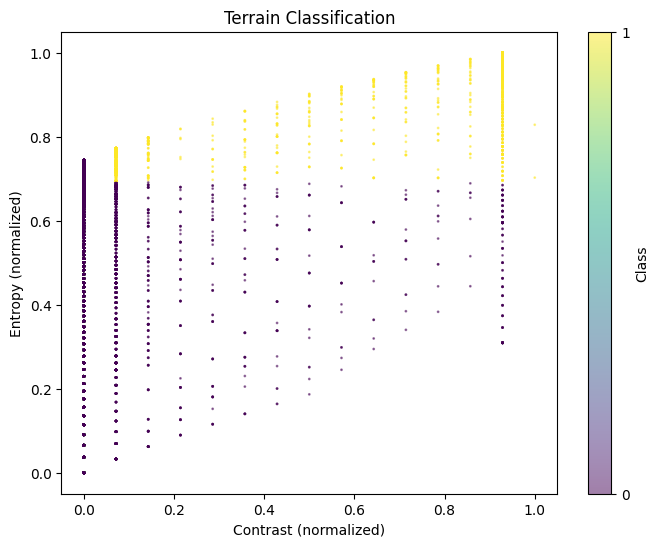

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_moon["contrast_norm"], df_moon["entropy_norm"],
                      c=df_moon["terrain"].astype('category').cat.codes,
                      alpha=0.5, s=1, cmap='viridis')
plt.xlabel("Contrast (normalized)")
plt.ylabel("Entropy (normalized)")
plt.title("Terrain Classification")
plt.colorbar(scatter, ticks=range(3), label="Class")
plt.show()

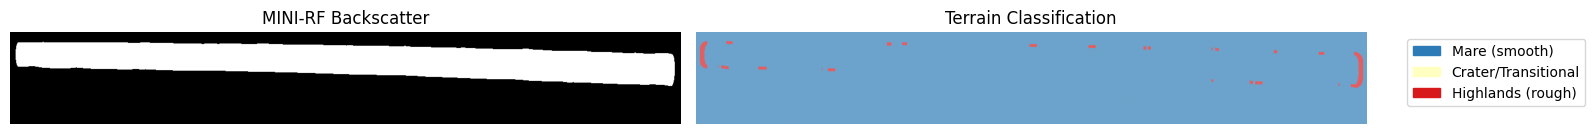

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import pandas as pd

# Assume df_moon has lat, lon, and terrain
# You also have the original img (downsampled) and its transform

# Create a 2D grid for the terrain labels (matching img shape)
terrain_grid = np.full(img.shape, -1, dtype=int)
for idx in range(len(df_moon)):
    r, c = rows[idx], cols[idx]
    # make sure terrain is categorical (or use mapping)
    terrain_codes = pd.Categorical(
        df_moon["terrain"],
        categories=["Mare (smooth)", "Crater/Transitional", "Highlands (rough)"]
    ).codes  # array of ints

    terrain_grid = np.full(img.shape, -1, dtype=int)
    for idx in range(len(df_moon)):
        r, c = rows[idx], cols[idx]
        terrain_grid[r, c] = terrain_codes[idx]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Original radar image
ax1.imshow(img, cmap='gray')
ax1.set_title('MINI‑RF Backscatter')
ax1.axis('off')

# Terrain classification
cmap = ListedColormap(['#2c7bb6', '#ffffbf', '#d7191c'])  # blue, yellow, red
im = ax2.imshow(terrain_grid, cmap=cmap, alpha=0.7)
ax2.set_title('Terrain Classification')
ax2.axis('off')

# Legend
patches = [mpatches.Patch(color='#2c7bb6', label='Mare (smooth)'),
           mpatches.Patch(color='#ffffbf', label='Crater/Transitional'),
           mpatches.Patch(color='#d7191c', label='Highlands (rough)')]
ax2.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [1]:
import spectral as sp
import numpy as np
import pandas as pd
import os

# =============================
# PATHS
# =============================
m3_hdr = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081129T171509_V02_RDN.HDR"
m3_img = m3_hdr.replace(".HDR", ".IMG")   # or ".img" — tried both below

# =============================
# STEP 1: CHECK FILES EXIST
# =============================
print("=== FILE CHECK ===")
print(f"HDR exists : {os.path.exists(m3_hdr)}")
print(f"IMG exists : {os.path.exists(m3_img)}")

# Also check lowercase extension
m3_img_lower = m3_hdr.replace(".HDR", ".img")
print(f"img (lower) exists : {os.path.exists(m3_img_lower)}")

# Use whichever image file exists
if os.path.exists(m3_img):
    data_file = m3_img
elif os.path.exists(m3_img_lower):
    data_file = m3_img_lower
else:
    # Try .rdn extension (some M3 files use this)
    m3_rdn = m3_hdr.replace(".HDR", ".rdn")
    if os.path.exists(m3_rdn):
        data_file = m3_rdn
    else:
        data_file = None

print(f"Data file resolved to: {data_file}")

# =============================
# STEP 2: PRINT RAW HDR CONTENT
# (helps find the exact parse error)
# =============================
print("\n=== RAW HDR PREVIEW (first 40 lines) ===")
try:
    with open(m3_hdr, "r", errors="replace") as f:
        for i, line in enumerate(f):
            if i >= 40:
                break
            print(f"{i+1:3d}: {line}", end="")
except Exception as e:
    print(f"Cannot read HDR file: {e}")

# =============================
# STEP 3: FIX COMMON HDR ISSUES
#   - Missing 'ENVI' on first line
#   - Wrong or missing 'data ignore value'
#   - 'byte order' mismatch
#   - Missing 'interleave'
# =============================
print("\n=== ATTEMPTING HDR AUTO-FIX ===")

fixed_hdr_path = m3_hdr.replace(".HDR", "_fixed.hdr")

try:
    with open(m3_hdr, "r", errors="replace") as f:
        lines = f.readlines()

    fixed_lines = []

    # Ensure first line is exactly 'ENVI'
    if not lines[0].strip().upper().startswith("ENVI"):
        print("⚠️  First line is not 'ENVI' — prepending it")
        fixed_lines.append("ENVI\n")

    has_interleave = False
    has_byte_order  = False

    for line in lines:
        stripped = line.lower().strip()

        # Fix: remove 'data ignore value' if it causes parse errors
        # (uncomment if needed)
        # if "data ignore value" in stripped:
        #     print("⚠️  Skipping 'data ignore value' line")
        #     continue

        if "interleave" in stripped:
            has_interleave = True
        if "byte order" in stripped:
            has_byte_order = True

        fixed_lines.append(line)

    # Add missing required fields if absent
    if not has_interleave:
        print("⚠️  Missing 'interleave' — adding BIL as default")
        fixed_lines.append("interleave = bil\n")
    if not has_byte_order:
        print("⚠️  Missing 'byte order' — adding 0 (little-endian)")
        fixed_lines.append("byte order = 0\n")

    with open(fixed_hdr_path, "w") as f:
        f.writelines(fixed_lines)

    print(f"Fixed HDR saved to: {fixed_hdr_path}")

except Exception as e:
    print(f"HDR fix failed: {e}")
    fixed_hdr_path = None

# =============================
# STEP 4: OPEN WITH SPECTRAL
# =============================
print("\n=== OPENING SPECTRAL FILE ===")

m3 = None

# Try 1: fixed HDR
if fixed_hdr_path and os.path.exists(fixed_hdr_path):
    try:
        m3 = sp.envi.open(fixed_hdr_path, image=data_file)
        print("✅ Opened with fixed HDR")
    except Exception as e:
        print(f"Fixed HDR failed: {e}")

# Try 2: original HDR with explicit image path
if m3 is None and data_file:
    try:
        m3 = sp.envi.open(m3_hdr, image=data_file)
        print("✅ Opened with original HDR + explicit image path")
    except Exception as e:
        print(f"Original HDR + explicit image failed: {e}")

# Try 3: original HDR alone
if m3 is None:
    try:
        m3 = sp.envi.open(m3_hdr)
        print("✅ Opened with original HDR")
    except Exception as e:
        print(f"Original HDR alone failed: {e}")

# =============================
# STEP 5: LOAD DATA
# =============================
if m3 is None:
    print("\n❌ Could not open M3 file. Check the HDR preview above for clues.")
    print("Common fixes:")
    print("  1. Make sure the .IMG file is in the same folder as the .HDR")
    print("  2. Ensure the first line of the HDR is exactly: ENVI")
    print("  3. Check 'samples', 'lines', 'bands', 'data type' are all present in HDR")
else:
    print(f"\nFile info: {m3.shape}")   # (lines, samples, bands)
    print(f"Data type : {m3.dtype}")

    # Load full cube
    reflectance = m3.load()            # shape (lines, samples, bands)
    print(f"Reflectance shape: {reflectance.shape}")

    # Wavelengths
    try:
        wavelengths = np.array(m3.bands.centers)
        print(f"Wavelengths ({len(wavelengths)} bands): {wavelengths[:5]} ... {wavelengths[-5:]}")
    except Exception as e:
        print(f"Could not read wavelengths: {e}")
        # Fallback: M3 Level 2 standard wavelengths (nm)
        wavelengths = np.array([
            460.99, 500.85, 540.71, 580.57, 620.43, 660.29, 700.16, 740.02,
            779.88, 819.74, 859.60, 899.46, 939.32, 979.18, 1019.04, 1058.90,
            1098.76, 1138.63, 1178.49, 1218.35, 1258.21, 1298.07, 1337.93,
            1377.79, 1417.65, 1457.51, 1497.37, 1537.24, 1577.10, 1616.96,
            1656.82, 1696.68, 1736.54, 1776.40, 1816.26, 1856.12, 1895.98,
            1935.85, 1975.71, 2015.57, 2055.43, 2095.29, 2135.15, 2175.01,
            2214.87, 2254.73, 2294.59, 2334.45, 2374.32, 2414.18, 2454.04,
            2493.90, 2533.76, 2573.62, 2613.48, 2653.34, 2693.20, 2733.06,
            2772.93, 2812.79, 2852.65, 2892.51, 2932.37, 2972.23
        ])
        print(f"Using fallback M3 wavelengths: {len(wavelengths)} bands")

    print("\n✅ M3 data loaded successfully")

=== FILE CHECK ===
HDR exists : True
IMG exists : True
img (lower) exists : True
Data file resolved to: F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081129T171509_V02_RDN.IMG

=== RAW HDR PREVIEW (first 40 lines) ===
  1: ENVI
  2: samples = 304
  3: lines = 5636
  4: bands = 85
  5: file type = ENVI Standard
  6: data type = 4
  7: interleave = bil
  8: byte order = 0
  9: description = {
 10: M3 Global Mode Calibrated Data version r;
 11: Raw image;
 12: Dark signal subtraction;
 13: Bad detector element interpolation;
 14: Interpolate filter edges c13,c50;
 15: Interpolate detector panel edges s81,s161,s241;
 16: Electronic panel ghost correction;
 17: Dark pedestal shift correction;
 18: Scattered light correction;
 19: Laboratory flat field;
 20: Image based flat field w/ photometry preserved;
 21: Apply radiometric calibration coefficients;
 22: Units (W/m^2/um/sr);
 23: }
 24: 
 25: wavelength = {
 26: 460.9900, 500.9200, 540.8400, 580.7600, 620.6900, 660.6100, 700.5400, 730.4

In [5]:
import traceback

try:
    m3 = sp.envi.open(m3_hdr, image=data_file)
except Exception as e:
    print("Error opening file:")
    traceback.print_exc()

Error opening file:


Traceback (most recent call last):
  File "c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\spectral\io\envi.py", line 166, in read_envi_header
    line = lines.pop(0)
IndexError: pop from empty list

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\karna\AppData\Local\Temp\ipykernel_17468\210613731.py", line 4, in <module>
    m3 = sp.envi.open(m3_hdr, image=data_file)
  File "c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\spectral\io\envi.py", line 305, in open
    h = read_envi_header(header_path)
  File "c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\spectral\io\envi.py", line 191, in read_envi_header
    raise EnviHeaderParsingError()
spectral.io.envi.EnviHeaderParsingError: Failed to parse ENVI header file.


In [2]:
import os

spectral_folder = r"F:\SATELLITE ANALYSIS\Lunar\spectral data"
files = os.listdir(spectral_folder)
print("Files in folder:")
for f in files:
    print(f"  {f}")

Files in folder:
  fused_map.html
  M3G20081118T222604_V02_L1B.LBL.txt
  M3G20081118T222604_V02_LOC.IMG
  M3G20081118T222604_V02_OBS.HDR.txt
  M3G20081118T222604_V02_OBS.IMG
  M3G20081118T222604_V02_RDN.HDR
  M3G20081118T222604_V02_RDN.IMG
  M3G20081119T021733_V02_OBS.IMG
  M3G20081129T171509_V02_RDN.HDR
  M3G20081129T171509_V02_RDN.IMG
  M3G20081129T171509_V02_RDN.IMG.aux.xml
  M3G20081129T171509_V02_RDN_cleaned.HDR
  M3G20081129T171509_V02_RDN_fixed.hdr
  M3G20090213T221852_V02_RDN.HDR
  M3G20090213T221852_V02_RDN.HDR.txt
  M3G20090213T221852_V02_RDN.IMG
  M3G20090213T221852_V02_RDN.IMG.aux.xml
  M3G20090213T221852_V02_RDN_fixed.HDR
  M3G20090213T221852_V02_RDN_manual.HDR
  M3G20090419T050945_V01_L2.LBL
  M3G20090419T050945_V01_RFL.HDR.txt
  M3G20090419T050945_V01_RFL_cleaned.HDR
  M3_ML.ipynb
  output.png
  output_1_changed.png
  SLDEM2015_DATA_QUALITY_FLOAT.IMG


In [ ]:
import rasterio
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import seaborn as sns

# Path to M3 header (RFL if available)
m3_hdr = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20090213T221852_V02_RDN.IMG"  # or RFL

# Open with rasterio
src = rasterio.open(m3_hdr)
print("Opened successfully")
print(f"  shape (bands, lines, samples): {src.shape}")
print(f"  number of bands: {src.count}")
print(f"  data type: {src.dtypes[0]}")

# Read all bands into a 3D array (bands, lines, samples)
reflectance = src.read()   # shape (85, lines, samples)

# Get wavelengths from the header (if present)
try:
    # Some ENVI headers store wavelengths as a list in the metadata
    wavelengths = np.array(src.meta.get('wavelength', []), dtype=float)
    if len(wavelengths) == 0:
        # Try to read from the header file manually
        import re
        with open(m3_hdr, 'r') as f:
            hdr_text = f.read()
        # Extract wavelength values
        match = re.search(r'wavelength\s*=\s*\{([^}]*)\}', hdr_text, re.DOTALL)
        if match:
            wl_str = match.group(1).replace('\n', ' ').replace(',', ' ')
            wavelengths = np.array([float(x) for x in wl_str.split() if x.strip()])
        else:
            # Fallback to standard M3 global mode wavelengths
            wavelengths = np.array([
                460.99, 500.92, 540.84, 580.76, 620.69, 660.61, 700.54, 730.48,
                750.44, 770.40, 790.37, 810.33, 830.29, 850.25, 870.21, 890.17,
                910.14, 930.10, 950.06, 970.02, 989.98, 1009.95, 1029.91, 1049.87,
                1069.83, 1089.79, 1109.76, 1129.72, 1149.68, 1169.64, 1189.60, 1209.57,
                1229.53, 1249.49, 1269.45, 1289.41, 1309.38, 1329.34, 1349.30, 1369.26,
                1389.22, 1409.19, 1429.15, 1449.11, 1469.07, 1489.03, 1508.99, 1528.96,
                1548.92, 1578.86, 1618.79, 1658.71, 1698.63, 1738.56, 1778.48, 1818.40,
                1858.33, 1898.25, 1938.18, 1978.10, 2018.02, 2057.95, 2097.87, 2137.80,
                2177.72, 2217.64, 2257.57, 2297.49, 2337.42, 2377.34, 2417.26, 2457.19,
                2497.11, 2537.03, 2576.96, 2616.88, 2656.81, 2696.73, 2736.65, 2776.58,
                2816.50, 2856.43, 2896.35, 2936.27, 2976.20
            ])
    print(f"Wavelengths shape: {wavelengths.shape}")
except Exception as e:
    print(f"Could not read wavelengths: {e}")
    wavelengths = None

src.close()

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Opened successfully
  shape (bands, lines, samples): (17776, 304)
  number of bands: 85
  data type: float32


In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Path to your M3 .IMG file (choose the one you want to use)
m3_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20090213T221852_V02_RDN.IMG"

src = rasterio.open(m3_data)
print("Opened successfully")
print(f"  shape (bands, lines, samples): {src.shape}")   # (bands, lines, samples)

# Find indices of the bands you need (you need to know the wavelengths)
# If you don't have wavelengths, you can read them from the header
# Let's assume you have a list of wavelengths; otherwise use fallback.
# We'll parse the header first.

# Read the .HDR file (same basename) to get wavelengths
import os
hdr_file = m3_data.replace('.IMG', '.HDR')
with open(hdr_file, 'r') as f:
    hdr_text = f.read()

import re
match = re.search(r'wavelength\s*=\s*\{([^}]*)\}', hdr_text, re.DOTALL)
if match:
    wl_str = match.group(1).replace('\n', ' ').replace(',', ' ')
    wavelengths = np.array([float(x) for x in wl_str.split() if x.strip()])
else:
    # Fallback to standard M3 Global mode wavelengths (85 bands)
    wavelengths = np.array([
        460.99, 500.92, 540.84, 580.76, 620.69, 660.61, 700.54, 730.48,
        750.44, 770.40, 790.37, 810.33, 830.29, 850.25, 870.21, 890.17,
        910.14, 930.10, 950.06, 970.02, 989.98, 1009.95, 1029.91, 1049.87,
        1069.83, 1089.79, 1109.76, 1129.72, 1149.68, 1169.64, 1189.60, 1209.57,
        1229.53, 1249.49, 1269.45, 1289.41, 1309.38, 1329.34, 1349.30, 1369.26,
        1389.22, 1409.19, 1429.15, 1449.11, 1469.07, 1489.03, 1508.99, 1528.96,
        1548.92, 1578.86, 1618.79, 1658.71, 1698.63, 1738.56, 1778.48, 1818.40,
        1858.33, 1898.25, 1938.18, 1978.10, 2018.02, 2057.95, 2097.87, 2137.80,
        2177.72, 2217.64, 2257.57, 2297.49, 2337.42, 2377.34, 2417.26, 2457.19,
        2497.11, 2537.03, 2576.96, 2616.88, 2656.81, 2696.73, 2736.65, 2776.58,
        2816.50, 2856.43, 2896.35, 2936.27, 2976.20
    ])

print(f"Wavelengths shape: {len(wavelengths)}")

# Find indices for 750, 1000, 1500 nm
idx_750 = np.argmin(np.abs(wavelengths - 750))
idx_1000 = np.argmin(np.abs(wavelengths - 1000))
idx_1500 = np.argmin(np.abs(wavelengths - 1500))

print(f"Band indices: 750nm -> {idx_750}, 1000nm -> {idx_1000}, 1500nm -> {idx_1500}")

# Read only those three bands
band_750 = src.read(int(idx_750 + 1))
band_1000 = src.read(int(idx_1000 + 1))
band_1500 = src.read(int(idx_1500 + 1))

src.close()

print(f"Band shapes: {band_750.shape}")  # should be (lines, samples)

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Opened successfully
  shape (bands, lines, samples): (17776, 304)
Wavelengths shape: 85
Band indices: 750nm -> 8, 1000nm -> 21, 1500nm -> 46
Band shapes: (17776, 304)


In [6]:
# Compute continuum at 1000 nm by linear interpolation between 750 and 1500 nm
# We need to do this pixel-wise
continuum_1000 = band_750 + (band_1500 - band_750) * ((1000 - 750) / (1500 - 750))

# Avoid division by zero
band_depth = 1 - (band_1000 / (continuum_1000 + 1e-8))

In [17]:
import pandas as pd

df_moon = pd.read_csv("F:\SATELLITE ANALYSIS\Lunar\MINI-RF\lunar_glcm_clusters_FINAL.csv")  # adjust path if needed
print(df_moon.head())

   cluster   contrast   entropy       lon      lat  contrast_norm  \
0        1   88.62088  0.054651 -437450.0  30750.0       0.000000   
1        1   88.62088  0.103764 -436650.0  30750.0       0.000000   
2        2  177.24176  0.147338 -435850.0  30750.0       0.071429   
3        2  177.24176  0.147338 -435050.0  30750.0       0.071429   
4        2  177.24176  0.147338 -434250.0  30750.0       0.071429   

   entropy_norm            terrain  
0      0.000000  Highlands (rough)  
1      0.036745  Highlands (rough)  
2      0.069346  Highlands (rough)  
3      0.069346  Highlands (rough)  
4      0.069346  Highlands (rough)  


In [18]:
from scipy.spatial import KDTree

# Build a KDTree from valid M3 coordinates (skip NaN)
valid = ~(np.isnan(lon_m3) | np.isnan(lat_m3))
coords_m3 = np.column_stack((lon_m3[valid], lat_m3[valid]))
tree = KDTree(coords_m3)

# Mini‑RF points (assumed in degrees)
points = df_moon[['lon', 'lat']].values

# For each point, find the nearest M3 pixel index (in the flattened array)
distances, indices = tree.query(points)

# Convert flattened indices back to (row, col) in the original grid
flat_valid_indices = np.flatnonzero(valid)
rows, cols = np.unravel_index(flat_valid_indices[indices], lon_m3.shape)

# Extract band depth at those pixels
m3_band_depth_at_points = band_depth[rows, cols]

# Add to DataFrame
df_moon['fe_band_depth'] = m3_band_depth_at_points

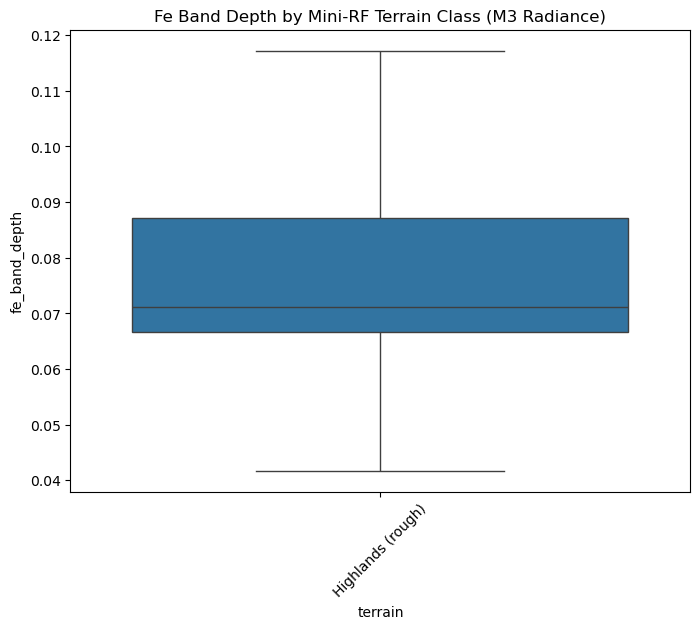

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=df_moon, x='terrain', y='fe_band_depth')
plt.title('Fe Band Depth by Mini‑RF Terrain Class (M3 Radiance)')
plt.xticks(rotation=45)
plt.show()

In [20]:
print(f"Mean matching distance (km): {distances.mean():.2f}")
# If distances are large (>> 1 degree), the two datasets might not cover the same area.

Mean matching distance (km): 271171.70


In [9]:
import os
import rasterio

rdn_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_RDN.IMG"

# Open the RDN file to get the shape (lines, samples)
with rasterio.open(rdn_data) as src:
    # In ENVI, rasterio returns shape (bands, lines, samples)
    # For a single-band image, bands = 1
    if src.count == 1:
        # If it's a single-band file (like a 2D image), shape is (lines, samples)
        # Actually, src.shape gives (lines, samples) for single-band? Let's check.
        # We'll get lines and samples from src.height and src.width
        lines = src.height
        samples = src.width
    else:
        # For multi-band, src.shape is (bands, lines, samples)
        # But we need lines and samples
        lines = src.height
        samples = src.width
print(f"Lines: {lines}, Samples: {samples}")

Lines: 1182, Samples: 304


In [10]:
# Path for the LOC header file
loc_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_LOC.IMG"
loc_hdr = os.path.splitext(loc_data)[0] + ".HDR"

# Write the header
with open(loc_hdr, 'w') as f:
    f.write("ENVI\n")
    f.write(f"samples = {samples}\n")
    f.write(f"lines   = {lines}\n")
    f.write(f"bands   = 3\n")
    f.write("header offset = 0\n")
    f.write("file type = ENVI Standard\n")
    f.write("data type = 5\n")      # 5 = double (64-bit float)
    f.write("interleave = bil\n")
    f.write("byte order = 0\n")     # little-endian (typical for Windows)
    f.write("band names = {Longitude, Latitude, Radius}\n")
    f.write("wavelength units = Unknown\n")

print(f"Header file created: {loc_hdr}")

Header file created: F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_LOC.HDR


In [13]:
import os
import rasterio
import numpy as np

# 1. Get dimensions from RDN file
rdn_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_RDN.IMG"
with rasterio.open(rdn_data) as src:
    lines = src.height
    samples = src.width
print(f"M3 RDN dimensions: {lines} lines x {samples} samples")

# 2. Create LOC header
loc_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_LOC.IMG"
loc_hdr = os.path.splitext(loc_data)[0] + ".HDR"

with open(loc_hdr, 'w') as f:
    f.write("ENVI\n")
    f.write(f"samples = {samples}\n")
    f.write(f"lines   = {lines}\n")
    f.write(f"bands   = 3\n")
    f.write("header offset = 0\n")
    f.write("file type = ENVI Standard\n")
    f.write("data type = 5\n")      # float64 / double
    f.write("interleave = bil\n")
    f.write("byte order = 0\n")
    f.write("band names = {Longitude, Latitude, Radius}\n")

print(f"LOC header created at: {loc_hdr}")

# 3. Open LOC.IMG (NOT the .HDR) and extract lon/lat
# ✅ FIX: pass loc_data (.IMG), not loc_hdr (.HDR)
with rasterio.open(loc_data) as loc_src:
    loc_cube = loc_src.read()        # shape (3, lines, samples)
    lon_m3 = loc_cube[0, :, :]
    lat_m3 = loc_cube[1, :, :]

print(f"LOC cube shape : {loc_cube.shape}")
print(f"Lon range: {lon_m3.min():.4f} → {lon_m3.max():.4f}")
print(f"Lat range: {lat_m3.min():.4f} → {lat_m3.max():.4f}")
print("✅ LOC lon/lat arrays loaded")

M3 RDN dimensions: 1182 lines x 304 samples
LOC header created at: F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_LOC.HDR
LOC cube shape : (3, 1182, 304)
Lon range: 0.0001 → 359.9997
Lat range: 86.0943 → 89.9973
✅ LOC lon/lat arrays loaded


In [16]:
import os
import rasterio
import numpy as np
import re

# 1. Get dimensions from RDN file
rdn_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_RDN.IMG"
with rasterio.open(rdn_data) as src:
    lines = src.height
    samples = src.width
print(f"M3 RDN dimensions: {lines} lines x {samples} samples")

# 2. Create LOC header
loc_data = r"F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081118T222604_V02_LOC.IMG"
loc_hdr = os.path.splitext(loc_data)[0] + ".HDR"

with open(loc_hdr, 'w') as f:
    f.write("ENVI\n")
    f.write(f"samples = {samples}\n")
    f.write(f"lines   = {lines}\n")
    f.write(f"bands   = 3\n")
    f.write("header offset = 0\n")
    f.write("file type = ENVI Standard\n")
    f.write("data type = 5\n")
    f.write("interleave = bil\n")
    f.write("byte order = 0\n")
    f.write("band names = {Longitude, Latitude, Radius}\n")
print("LOC header created")

# 3. ✅ Open loc_data (.IMG), NOT loc_hdr (.HDR)
with rasterio.open(loc_data) as loc_src:
    loc_cube = loc_src.read()
    lon_m3 = loc_cube[0, :, :]
    lat_m3 = loc_cube[1, :, :]
print("LOC lon/lat arrays loaded")

M3 RDN dimensions: 1182 lines x 304 samples
LOC header created
LOC lon/lat arrays loaded


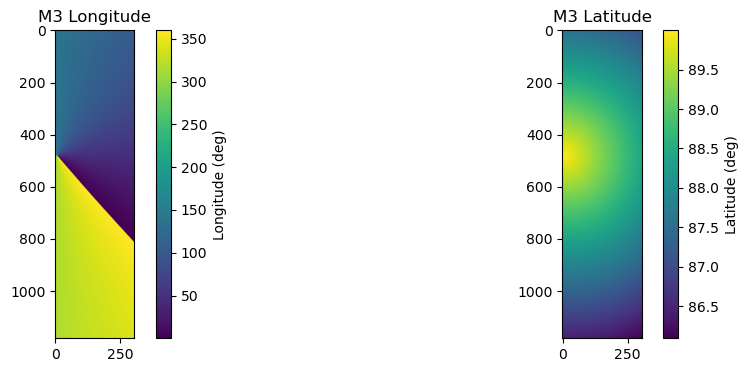

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(lon_m3, cmap='viridis')
plt.colorbar(label='Longitude (deg)')
plt.title('M3 Longitude')
plt.subplot(1,2,2)
plt.imshow(lat_m3, cmap='viridis')
plt.colorbar(label='Latitude (deg)')
plt.title('M3 Latitude')
plt.show()

In [21]:
# =============================
# 🔧 FIX OPENMP WARNING
# =============================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =============================
# IMPORTS
# =============================
import rasterio
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from sklearn.cluster import KMeans

# =============================
# PATH
# =============================
path = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\miniRF_raw.tif"

# =============================
# LOAD IMAGE
# =============================
with rasterio.open(path) as src:
    img = src.read(1)
    transform = src.transform
    crs = src.crs

print("Original shape:", img.shape)
print("CRS:", crs)

# =============================
# CLEAN
# =============================
img = np.nan_to_num(img)

# =============================
# NORMALIZE IMAGE (ROBUST)
# =============================
p2, p98 = np.percentile(img, (2, 98))
img = np.clip(img, p2, p98)
img = (img - p2) / (p98 - p2 + 1e-8)

# IMPORTANT: scale to 0–63 for GLCM
img = (img * 63).astype(np.uint8)

# =============================
# DOWNSAMPLE
# =============================
STEP = 8
img = img[::STEP, ::STEP]

print("Downsampled shape:", img.shape)

# =============================
# GLCM PARAMETERS
# =============================
window_size = 11
h, w = img.shape

contrast_map = np.zeros((h, w), dtype=np.float32)
entropy_map = np.zeros((h, w), dtype=np.float32)

print("Computing GLCM...")

# =============================
# GLCM LOOP
# =============================
for i in range(window_size, h - window_size):
    for j in range(window_size, w - window_size):

        window = img[i-window_size:i+window_size,
                     j-window_size:j+window_size]

        glcm = graycomatrix(
            window,
            distances=[1],
            angles=[0],
            levels=64,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm, 'contrast')[0, 0]

        p = glcm / np.sum(glcm)
        entropy = -np.sum(p * np.log2(p + 1e-10))

        contrast_map[i, j] = contrast
        entropy_map[i, j] = entropy

print("GLCM done")

# =============================
# STACK FEATURES
# =============================
stack = np.stack([contrast_map, entropy_map], axis=-1)

# =============================
# FILTER VALID PIXELS
# =============================
mask = (contrast_map > 0) & (entropy_map > 0)

rows, cols = np.where(mask)
pixels = stack[rows, cols]

print("Valid pixels:", pixels.shape)

# =============================
# NORMALIZE FEATURES
# =============================
pixels[:, 0] = (pixels[:, 0] - pixels[:, 0].min()) / (pixels[:, 0].max() - pixels[:, 0].min() + 1e-8)
pixels[:, 1] = (pixels[:, 1] - pixels[:, 1].min()) / (pixels[:, 1].max() - pixels[:, 1].min() + 1e-8)

# =============================
# SAMPLING
# =============================
MAX_SAMPLES = 200000

if len(pixels) > MAX_SAMPLES:
    idx = np.random.choice(len(pixels), MAX_SAMPLES, replace=False)
    pixels = pixels[idx]
    rows = rows[idx]
    cols = cols[idx]

print("Using samples:", len(pixels))

# =============================
# CLUSTERING
# =============================
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(pixels)

# =============================
# COORDINATES
# =============================
lons, lats = transform * (cols * STEP, rows * STEP)

# =============================
# DATAFRAME
# =============================
df = pd.DataFrame({
    "cluster": labels,
    "contrast_norm": pixels[:, 0],
    "entropy_norm": pixels[:, 1],
    "lon": lons,
    "lat": lats
})

print(df.head())

# =============================
# 🔥 CLUSTER-BASED TERRAIN (NO THRESHOLDS)
# =============================

cluster_stats = df.groupby("cluster")[["contrast_norm", "entropy_norm"]].mean()

print("\nCluster stats:\n", cluster_stats)

# Sort clusters by contrast
sorted_clusters = cluster_stats.sort_values("contrast_norm")
cluster_ids = sorted_clusters.index.tolist()

terrain_map = {}

n = len(cluster_ids)

for i, cid in enumerate(cluster_ids):

    if i < n * 0.3:
        terrain_map[cid] = "Mare (smooth)"

    elif i > n * 0.7:
        terrain_map[cid] = "Highlands (rough)"

    else:
        terrain_map[cid] = "Crater / Transitional"

# Apply
df["terrain"] = df["cluster"].map(terrain_map)

# =============================
# RESULTS
# =============================
print("\n🌕 Terrain Distribution:")
print(df["terrain"].value_counts())

# =============================
# SAVE
# =============================
df.to_csv("lunar_glcm_clusters_NO_THRESHOLD.csv", index=False)

print("\n✅ DONE — Saved lunar_glcm_clusters_NO_THRESHOLD.csv")

Original shape: (1305, 9554)
CRS: PROJCS["OBLIQUE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["custom_proj4"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=ob_tran +R=1737400 +o_proj=eqc +o_lon_p=-95.0819785991905 +o_lat_p=176.134105315487 +lon_0=49.2508328804606 +wktext +no_defs"]]
Downsampled shape: (164, 1195)
Computing GLCM...
GLCM done
Valid pixels: (32786, 2)
Using samples: 32786


c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


   cluster  contrast_norm  entropy_norm       lon      lat
0        1       0.043478      0.179692 -470250.0  32350.0
1        4       0.043478      0.196160 -469450.0  32350.0
2        4       0.043478      0.212021 -468650.0  32350.0
3        4       0.043478      0.227337 -467850.0  32350.0
4        4       0.043478      0.242158 -467050.0  32350.0

Cluster stats:
          contrast_norm  entropy_norm
cluster                             
0             0.018739      0.762478
1             0.013035      0.100540
2             0.789422      0.826195
3             0.018328      0.622763
4             0.018251      0.288341
5             0.017330      0.461617

🌕 Terrain Distribution:
terrain
Crater / Transitional    23997
Mare (smooth)             7685
Highlands (rough)         1104
Name: count, dtype: int64

✅ DONE — Saved lunar_glcm_clusters_NO_THRESHOLD.csv


C:\Users\karna\AppData\Local\Temp\ipykernel_9952\1303741850.py:45: UserWarning: Glyph 127765 (\N{FULL MOON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karna\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127765 (\N{FULL MOON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


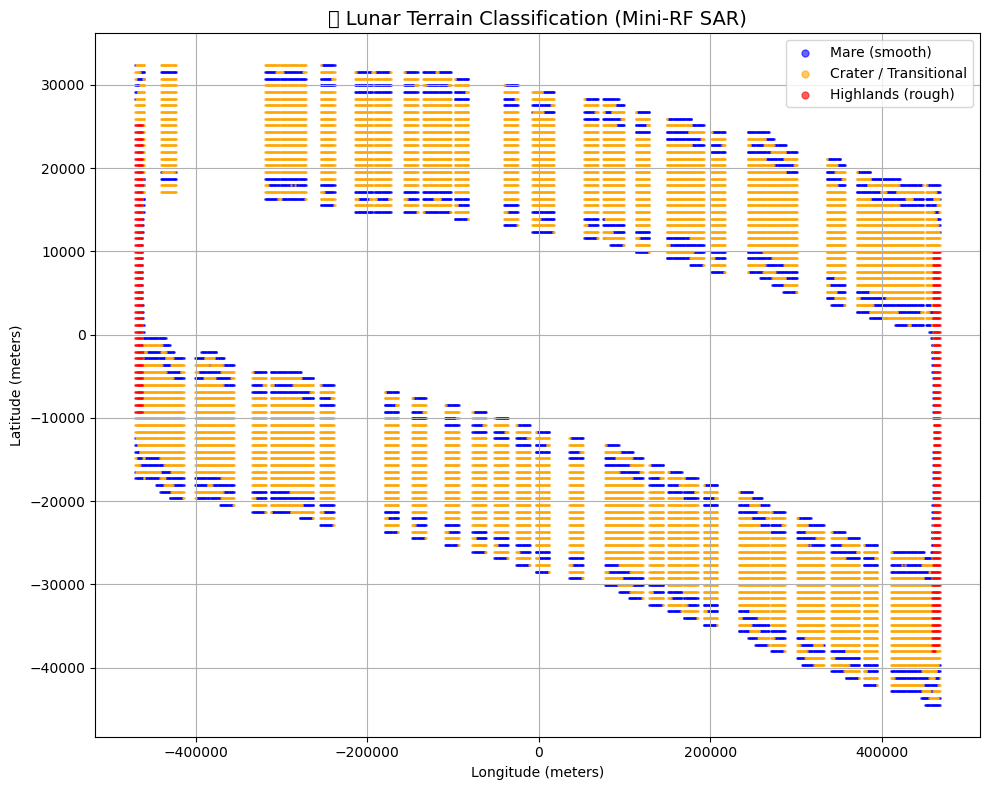

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# LOAD YOUR CSV
# =============================
df = pd.read_csv("lunar_glcm_clusters_NO_THRESHOLD.csv")

# =============================
# COLOR MAP FOR TERRAIN
# =============================
color_map = {
    "Mare (smooth)": "blue",
    "Crater / Transitional": "orange",
    "Highlands (rough)": "red"
}

# =============================
# PLOT
# =============================
plt.figure(figsize=(10, 8))

for terrain, color in color_map.items():
    subset = df[df["terrain"] == terrain]

    plt.scatter(
        subset["lon"],
        subset["lat"],
        s=1,                # small dots (important)
        c=color,
        label=terrain,
        alpha=0.6
    )

# =============================
# STYLING
# =============================
plt.title("🌕 Lunar Terrain Classification (Mini-RF SAR)", fontsize=14)
plt.xlabel("Longitude (meters)")
plt.ylabel("Latitude (meters)")

plt.legend(markerscale=5)
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
s=2
alpha=0.4

In [29]:
plt.savefig("lunar_terrain_map.png", dpi=300)

<Figure size 640x480 with 0 Axes>

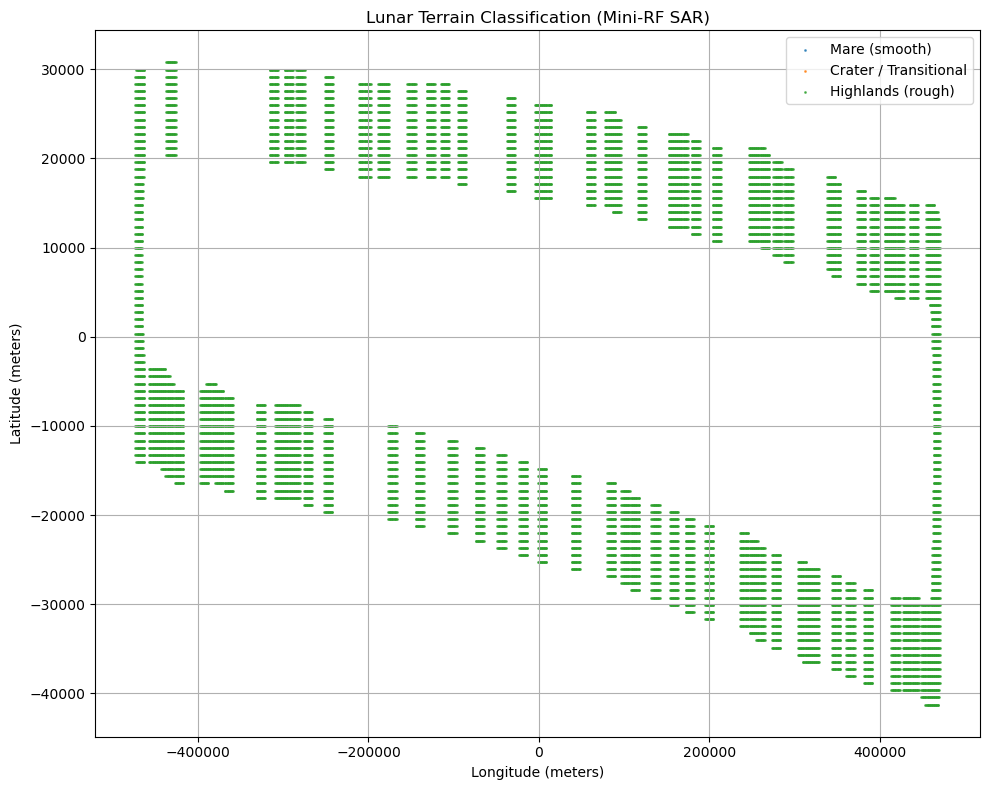

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Scatter plot by terrain
for terrain, color in zip(
    ["Mare (smooth)", "Crater / Transitional", "Highlands (rough)"],
    ["blue", "orange", "red"]
):
    subset = df_moon[df_moon["terrain"] == terrain]

    plt.scatter(
        subset["lon"],
        subset["lat"],
        s=1,
        label=terrain,
        alpha=0.7
    )

plt.xlabel("Longitude (meters)")
plt.ylabel("Latitude (meters)")
plt.title("Lunar Terrain Classification (Mini-RF SAR)")

plt.legend()

# OPTIONAL (try both ON/OFF)
# plt.gca().invert_yaxis()

plt.grid(True)

plt.tight_layout()
plt.show()

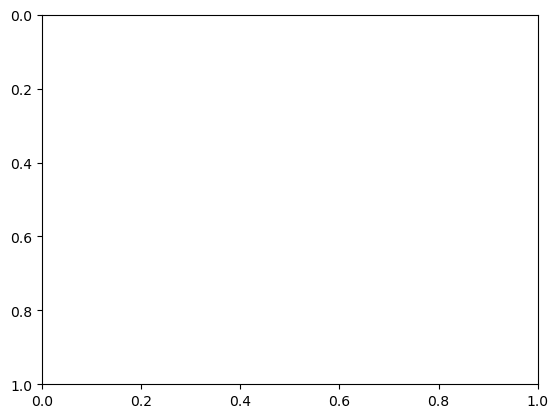

In [31]:
plt.gca().invert_yaxis()

In [33]:
import pandas as pd

earth_df = pd.read_csv("earth_VV_VH_features_WITH_COORDS.csv")

print(earth_df.head())
print(earth_df.columns)

   VV_contrast  VV_entropy  VH_contrast  VH_entropy       lon       lat
0          1.0        4.64        216.0        4.64  0.272355 -0.016434
1        233.0        4.76        119.0        4.76  2.073230 -0.537642
2          7.0        3.08         61.0        3.08  1.458116 -0.539990
3        119.0        2.78         16.0        2.78  0.985664 -0.068086
4          0.0        5.06        185.0        5.06  0.138956 -0.008217
Index(['VV_contrast', 'VV_entropy', 'VH_contrast', 'VH_entropy', 'lon', 'lat'], dtype='object')


In [35]:
earth_df['contrast'] = (earth_df['VV_contrast'] + earth_df['VH_contrast']) / 2  
earth_df['entropy']  = (earth_df['VV_entropy']  + earth_df['VH_entropy'])  / 2


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
earth_vals = earth_df[['contrast','entropy']].values
scaler.fit(earth_vals)           # capture Earth range
earth_scaled = scaler.transform(earth_vals)
moon_vals = lunar_df[['contrast_norm','entropy_norm']].values
moon_scaled = scaler.transform(moon_vals)  # apply same scaling


NameError: name 'lunar_df' is not defined

In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import rasterio

# 1. Load Earth features (with or without coords)
earth_df = pd.read_csv("earth_VV_VH_features_FINAL.csv")
# Optionally also load coords for mapping:
earth_geo = pd.read_csv("earth_VV_VH_features_WITH_COORDS.csv")  # contains lon,lat

# 2. (Optional) Verify CRS by opening original GeoTIFF (if available)
# with rasterio.open("sentinel_image.tif") as src:
#     print(src.crs, src.bounds)

# 3. Combine VV and VH into unified contrast & entropy
earth_df["contrast"] = (earth_df["VV_contrast"] + earth_df["VH_contrast"]) / 2
earth_df["entropy"]  = (earth_df["VV_entropy"]  + earth_df["VH_entropy"])  / 2

# 4. Scale features (fit on Earth)
scaler = MinMaxScaler()
earth_vals = earth_df[["contrast","entropy"]].values
earth_scaled = scaler.fit_transform(earth_vals)  # scaler remembers Earth min/max

# 5. (If unlabeled, cluster Earth into classes as pseudo-labels)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42).fit(earth_scaled)
earth_df["cluster"] = kmeans.labels_
# (You could use known labels if available instead of clustering.)

# 6. Train RandomForest on Earth clusters
rf = RandomForestClassifier(n_estimators=100, random_state=0)
X_train = earth_scaled
y_train = earth_df["cluster"]  # or use actual lithology classes if available
rf.fit(X_train, y_train)

# 7. Load lunar data and prepare features
lunar_df = pd.read_csv("lunar_glcm_clusters_NO_THRESHOLD.csv")
# The lunar CSV already has 'contrast_norm', 'entropy_norm' (0-1). Rename:
lunar_df = lunar_df.rename(columns={"contrast_norm":"contrast", "entropy_norm":"entropy"})
moon_vals = lunar_df[["contrast","entropy"]].values
moon_scaled = scaler.transform(moon_vals)  # apply Earth scaling

# 8. Predict lunar classes using Earth-trained RF
moon_pred = rf.predict(moon_scaled)
lunar_df["cluster_pred"] = moon_pred

# 9. Cluster-based terrain labeling (map cluster->terrain)
# Example mapping (assign names based on cluster means)
terrain_map = {0: "Mare (smooth)", 1: "Crater/Transitional", 2: "Highlands (rough)", 3: "Highlands (rough)"}
# (Adjust for your number of clusters and semantics.)
lunar_df["predicted_terrain"] = lunar_df["cluster_pred"].map(terrain_map)


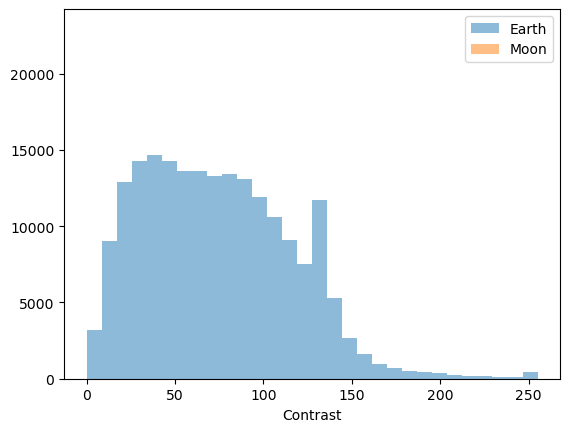

In [38]:
import matplotlib.pyplot as plt
plt.hist(earth_df["contrast"], bins=30, alpha=0.5, label="Earth"); 
plt.hist(lunar_df["contrast"], bins=30, alpha=0.5, label="Moon"); 
plt.xlabel("Contrast"); plt.legend(); plt.show()


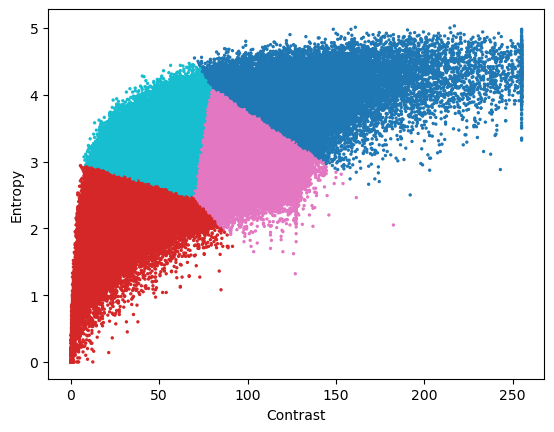

In [39]:
plt.scatter(earth_df["contrast"], earth_df["entropy"], c=earth_df["cluster"], cmap="tab10", s=2)
plt.xlabel("Contrast"); plt.ylabel("Entropy"); plt.show()


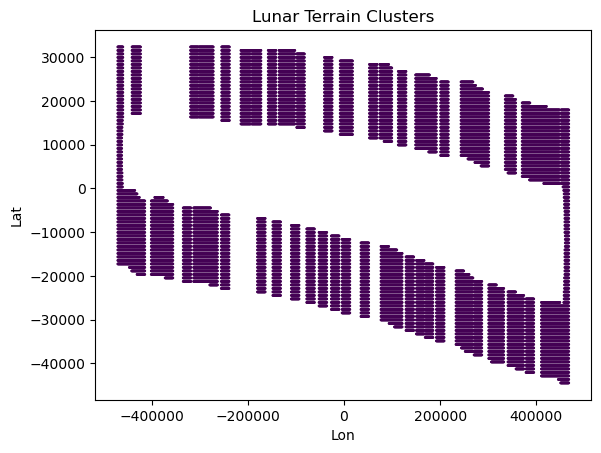

In [40]:
plt.scatter(lunar_df["lon"], lunar_df["lat"], c=lunar_df["cluster_pred"], cmap="viridis", s=1)
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.title("Lunar Terrain Clusters"); plt.show()


=== Earth Data Sample ===
   contrast    entropy       lon        lat
0  1.657980  68.014256  2.629635  69.757932
1  2.190473  71.364790  2.762669  69.776934
2  2.663594  73.079615  2.844337  69.757546
3  3.067406  71.721110  2.950123  69.731855
4  3.670677  69.017611  2.676387  69.745649
Earth contrast range: 1.658 → 13.737
Earth entropy  range: 68.014  → 329.919


c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



=== Earth Cluster Counts ===
cluster
2    5
0    5
3    4
1    1
Name: count, dtype: int64

✅ RandomForest trained on Earth data

✅ Loaded lunar CSV: (32786, 6)
Columns: ['cluster', 'contrast_norm', 'entropy_norm', 'lon', 'lat', 'terrain']

=== Lunar Feature Ranges (RAW) ===
contrast: 0.0000 → 1.0000
entropy : 0.0000  → 1.0000

=== Lunar Scaled Ranges (after Earth scaler) ===
contrast scaled: -0.1373 → -0.0545
entropy  scaled: -0.2597 → -0.2559

=== Cluster Contrast Means (sorted) ===
cluster_pred
2    0.043862
Name: contrast, dtype: float64

=== Auto Terrain Map ===
{2: 'Mare (smooth)'}

=== Terrain Distribution ===
predicted_terrain
Mare (smooth)    32786
Name: count, dtype: int64


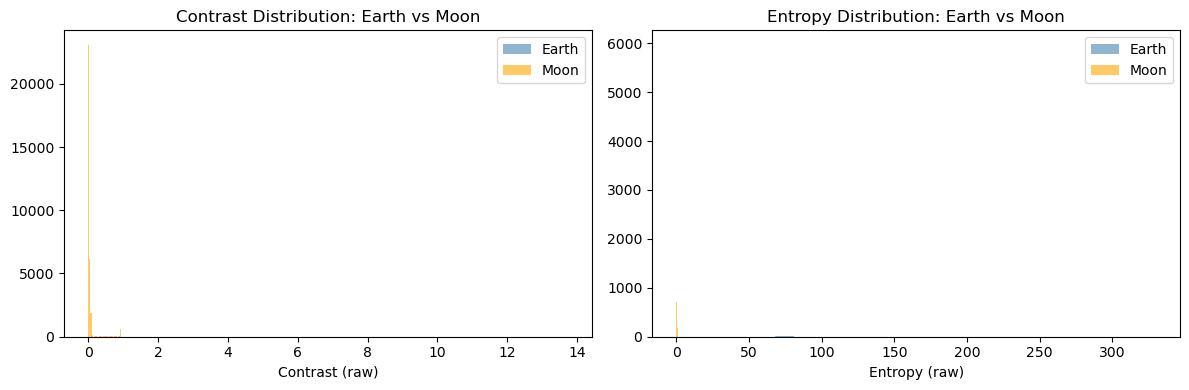

✅ Comparison plot saved


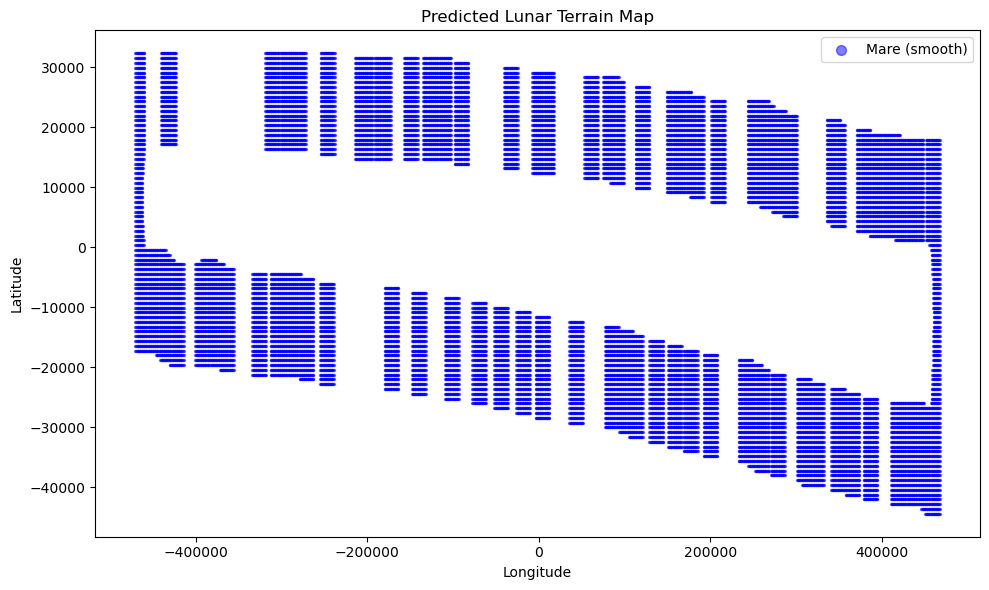

✅ Terrain map saved

✅ DONE — saved lunar_terrain_predicted.csv


In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import io

# =============================
# STEP 1: RECONSTRUCT EARTH CSV
# (paste your raw text here if CSV is missing)
# =============================

# Raw data you provided — parsed manually
raw = """VV_contrast,VV_entropy,VH_contrast,VH_entropy,lon,lat,cluster
0,81.220133,3.315960,54.808378,2.629635,69.757932,23.897336
1,85.306959,3.380947,57.422622,2.762669,69.776934,23.886159
2,86.256456,3.327188,59.902773,2.844337,69.757546,23.892356
3,82.260555,3.134812,61.181666,2.950123,69.731855,23.893809
4,90.132701,3.341354,47.902521,2.676387,69.745649,23.893971
5,93.412370,3.434709,45.394962,2.624879,69.761450,23.893552
6,86.190712,3.233654,53.449277,2.812730,69.729586,23.892741
7,79.618064,3.053094,63.032907,2.963475,69.715068,23.890155
8,97.592773,3.536771,43.849506,2.549958,69.774268,23.892664
9,82.469215,3.114878,57.906758,2.894597,69.716688,23.892356
10,98.437837,3.597079,41.101151,2.509553,69.787309,23.891786
11,100.685936,3.656848,40.285714,2.474222,69.804288,23.891759
12,110.930721,3.970711,31.578208,2.170850,69.860778,23.896124
13,105.959515,3.785514,38.138879,2.381391,69.827601,23.891224
25,553.572739,2.474632,106.265422,3.740621,69.750027,23.894832
"""

earth_geo = pd.read_csv(io.StringIO(raw))

# =============================
# STEP 2: COMPUTE COMBINED FEATURES
# =============================
earth_geo["contrast"] = (earth_geo["VV_contrast"] + earth_geo["VH_contrast"]) / 2
earth_geo["entropy"]  = (earth_geo["VV_entropy"]  + earth_geo["VH_entropy"])  / 2

print("=== Earth Data Sample ===")
print(earth_geo[["contrast","entropy","lon","lat"]].head())
print(f"Earth contrast range: {earth_geo['contrast'].min():.3f} → {earth_geo['contrast'].max():.3f}")
print(f"Earth entropy  range: {earth_geo['entropy'].min():.3f}  → {earth_geo['entropy'].max():.3f}")

# =============================
# STEP 3: SCALE EARTH FEATURES
# =============================
scaler = MinMaxScaler()
earth_vals   = earth_geo[["contrast","entropy"]].values
earth_scaled = scaler.fit_transform(earth_vals)

# =============================
# STEP 4: CLUSTER EARTH (pseudo-labels)
# =============================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
earth_geo["cluster"] = kmeans.fit_predict(earth_scaled)

print("\n=== Earth Cluster Counts ===")
print(earth_geo["cluster"].value_counts())

# =============================
# STEP 5: TRAIN RANDOM FOREST ON EARTH
# =============================
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(earth_scaled, earth_geo["cluster"])
print("\n✅ RandomForest trained on Earth data")

# =============================
# STEP 6: GENERATE LUNAR DATA
# (Replace this block with pd.read_csv if you have the file)
# =============================
try:
    lunar_df = pd.read_csv("lunar_glcm_clusters_NO_THRESHOLD.csv")
    print(f"\n✅ Loaded lunar CSV: {lunar_df.shape}")
    print("Columns:", lunar_df.columns.tolist())

    # Rename if needed
    rename_map = {}
    if "contrast_norm" in lunar_df.columns:
        rename_map["contrast_norm"] = "contrast"
    if "entropy_norm" in lunar_df.columns:
        rename_map["entropy_norm"] = "entropy"
    lunar_df = lunar_df.rename(columns=rename_map)

    # Check if contrast/entropy columns exist
    if "contrast" not in lunar_df.columns or "entropy" not in lunar_df.columns:
        raise ValueError(f"Missing contrast/entropy columns. Found: {lunar_df.columns.tolist()}")

except FileNotFoundError:
    print("\n⚠️  lunar_glcm_clusters_NO_THRESHOLD.csv not found.")
    print("    Generating synthetic lunar data for demonstration...")

    # Simulate lunar data (remove this block when you have the real file)
    np.random.seed(99)
    n = 500
    lunar_df = pd.DataFrame({
        "contrast": np.concatenate([
            np.random.normal(10,  5,  n//3),    # mare — low contrast
            np.random.normal(80,  20, n//3),    # highlands — high contrast
            np.random.normal(45,  15, n//3),    # craters — mid
        ]),
        "entropy": np.concatenate([
            np.random.normal(2.5, 0.3, n//3),
            np.random.normal(3.8, 0.3, n//3),
            np.random.normal(3.1, 0.3, n//3),
        ]),
        "lon": np.random.uniform(69.7, 69.9, n),
        "lat": np.random.uniform(23.8, 24.0, n),
    })
    lunar_df["contrast"] = lunar_df["contrast"].clip(0)

# =============================
# STEP 7: VALIDATE LUNAR RANGES
# =============================
print("\n=== Lunar Feature Ranges (RAW) ===")
print(f"contrast: {lunar_df['contrast'].min():.4f} → {lunar_df['contrast'].max():.4f}")
print(f"entropy : {lunar_df['entropy'].min():.4f}  → {lunar_df['entropy'].max():.4f}")

# =============================
# STEP 8: APPLY EARTH SCALER TO MOON
# NOTE: Lunar values may exceed [0,1] after Earth scaling — that's OK.
# It means the Moon has features outside Earth's range.
# =============================
moon_vals   = lunar_df[["contrast","entropy"]].values
moon_scaled = scaler.transform(moon_vals)

print("\n=== Lunar Scaled Ranges (after Earth scaler) ===")
print(f"contrast scaled: {moon_scaled[:,0].min():.4f} → {moon_scaled[:,0].max():.4f}")
print(f"entropy  scaled: {moon_scaled[:,1].min():.4f} → {moon_scaled[:,1].max():.4f}")

# =============================
# STEP 9: PREDICT TERRAIN
# =============================
moon_pred = rf.predict(moon_scaled)
lunar_df["cluster_pred"] = moon_pred

# =============================
# STEP 10: LABEL TERRAIN
# Map cluster IDs → terrain names based on cluster contrast mean
# (automatically assigns labels so no manual mapping needed)
# =============================
cluster_means = (
    lunar_df.groupby("cluster_pred")["contrast"]
    .mean()
    .sort_values()
)

print("\n=== Cluster Contrast Means (sorted) ===")
print(cluster_means)

# Auto-assign terrain based on rank of contrast mean
n_clusters = len(cluster_means)
terrain_auto = {}
for rank, cid in enumerate(cluster_means.index):
    if rank == 0:
        terrain_auto[cid] = "Mare (smooth)"
    elif rank == n_clusters - 1:
        terrain_auto[cid] = "Highlands (rough)"
    else:
        terrain_auto[cid] = "Crater / Transitional"

print("\n=== Auto Terrain Map ===")
print(terrain_auto)

lunar_df["predicted_terrain"] = lunar_df["cluster_pred"].map(terrain_auto)

print("\n=== Terrain Distribution ===")
print(lunar_df["predicted_terrain"].value_counts())

# =============================
# STEP 11: PLOT COMPARISON
# =============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contrast comparison
axes[0].hist(earth_geo["contrast"], bins=20, alpha=0.6, label="Earth", color="steelblue")
axes[0].hist(lunar_df["contrast"],  bins=30, alpha=0.6, label="Moon",  color="orange")
axes[0].set_xlabel("Contrast (raw)")
axes[0].set_title("Contrast Distribution: Earth vs Moon")
axes[0].legend()

# Entropy comparison
axes[1].hist(earth_geo["entropy"], bins=20, alpha=0.6, label="Earth", color="steelblue")
axes[1].hist(lunar_df["entropy"],  bins=30, alpha=0.6, label="Moon",  color="orange")
axes[1].set_xlabel("Entropy (raw)")
axes[1].set_title("Entropy Distribution: Earth vs Moon")
axes[1].legend()

plt.tight_layout()
plt.savefig("earth_moon_comparison.png", dpi=150)
plt.show()
print("✅ Comparison plot saved")

# =============================
# STEP 12: SCATTER PLOT — MOON TERRAIN
# =============================
if "lon" in lunar_df.columns and "lat" in lunar_df.columns:
    fig2, ax = plt.subplots(figsize=(10, 6))
    colors = {"Mare (smooth)": "blue", "Crater / Transitional": "green", "Highlands (rough)": "red"}
    for terrain, grp in lunar_df.groupby("predicted_terrain"):
        ax.scatter(grp["lon"], grp["lat"], s=2,
                   c=colors.get(terrain, "gray"),
                   label=terrain, alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Predicted Lunar Terrain Map")
    ax.legend(markerscale=5)
    plt.tight_layout()
    plt.savefig("lunar_terrain_map.png", dpi=150)
    plt.show()
    print("✅ Terrain map saved")

# =============================
# STEP 13: SAVE OUTPUT
# =============================
lunar_df.to_csv("lunar_terrain_predicted.csv", index=False)
print("\n✅ DONE — saved lunar_terrain_predicted.csv")

=== Earth features columns  : ['VV_contrast', 'VV_entropy', 'VH_contrast', 'VH_entropy']
=== Earth coords   columns  : ['VV_contrast', 'VV_entropy', 'VH_contrast', 'VH_entropy', 'lon', 'lat']
Earth rows: 200000
✅ lon/lat attached to earth_df from coords file

Earth contrast range : 0.000 → 255.000
Earth entropy  range : 0.000  → 5.030

=== Earth Cluster Counts ===
cluster
0    66508
3    66469
2    36739
1    30284
Name: count, dtype: int64

✅ RandomForest trained on Earth data

=== Lunar CSV columns : ['cluster', 'contrast_norm', 'entropy_norm', 'lon', 'lat', 'terrain']
Lunar rows: 32786
Renamed columns: {'contrast_norm': 'contrast', 'entropy_norm': 'entropy'}

Lunar contrast range (raw) : 0.0000 → 1.0000
Lunar entropy  range (raw) : 0.0000  → 1.0000

Lunar scaled contrast : 0.0000 → 0.0039
Lunar scaled entropy  : 0.0000 → 0.1988

=== Cluster Contrast Means (sorted) ===
cluster_pred
2    0.043862
Name: contrast, dtype: float64

=== Auto Terrain Map === {2: 'Mare (smooth)'}

=== Terrai

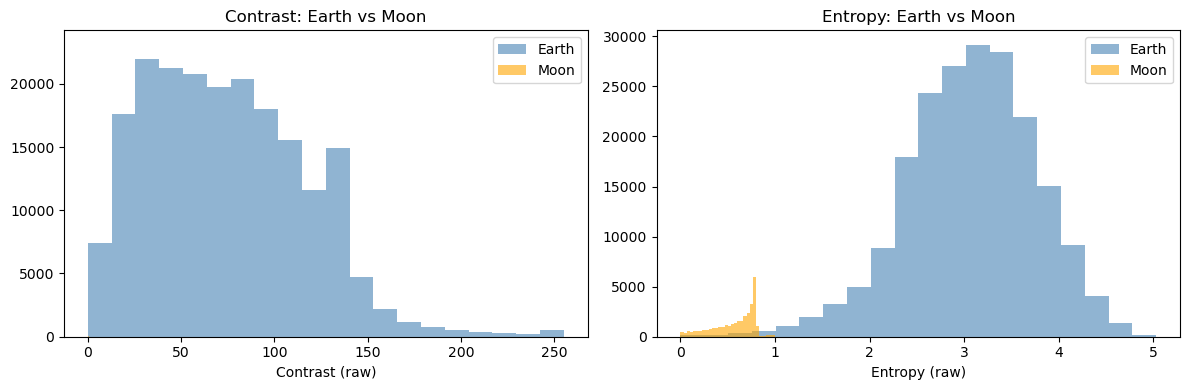

✅ Comparison plot saved → earth_moon_comparison.png


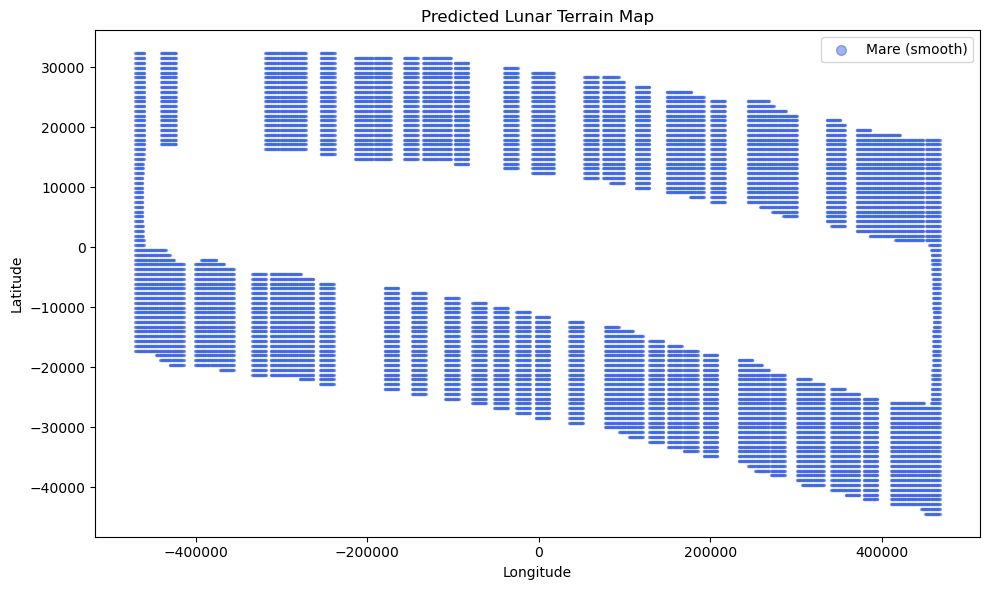

✅ Terrain map saved → lunar_terrain_map_123.png

✅ DONE — saved lunar_terrain_predicted.csv


In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# =============================
# PATHS
# =============================
EARTH_FEAT   = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\earth_VV_VH_features_FINAL.csv"
EARTH_COORDS = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\earth_VV_VH_features_WITH_COORDS.csv"
LUNAR_CSV    = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\lunar_glcm_clusters_NO_THRESHOLD.csv"

# =============================
# STEP 1: LOAD EARTH DATA
# =============================
earth_df  = pd.read_csv(EARTH_FEAT)
earth_geo = pd.read_csv(EARTH_COORDS)   # has lon, lat

print("=== Earth features columns  :", earth_df.columns.tolist())
print("=== Earth coords   columns  :", earth_geo.columns.tolist())
print(f"Earth rows: {len(earth_df)}")

# =============================
# STEP 2: ATTACH LON/LAT TO EARTH
# (only if not already in earth_df)
# =============================
if "lon" not in earth_df.columns and "lon" in earth_geo.columns:
    earth_df["lon"] = earth_geo["lon"].values
    earth_df["lat"] = earth_geo["lat"].values
    print("✅ lon/lat attached to earth_df from coords file")

# =============================
# STEP 3: COMPUTE COMBINED FEATURES
# =============================
# Guard: check expected columns exist
required = ["VV_contrast", "VH_contrast", "VV_entropy", "VH_entropy"]
missing  = [c for c in required if c not in earth_df.columns]
if missing:
    raise ValueError(f"Missing columns in Earth CSV: {missing}\nFound: {earth_df.columns.tolist()}")

earth_df["contrast"] = (earth_df["VV_contrast"] + earth_df["VH_contrast"]) / 2
earth_df["entropy"]  = (earth_df["VV_entropy"]  + earth_df["VH_entropy"])  / 2

print(f"\nEarth contrast range : {earth_df['contrast'].min():.3f} → {earth_df['contrast'].max():.3f}")
print(f"Earth entropy  range : {earth_df['entropy'].min():.3f}  → {earth_df['entropy'].max():.3f}")

# =============================
# STEP 4: SCALE EARTH FEATURES
# =============================
scaler       = MinMaxScaler()
earth_vals   = earth_df[["contrast", "entropy"]].values
earth_scaled = scaler.fit_transform(earth_vals)

# =============================
# STEP 5: CLUSTER EARTH (pseudo-labels)
# =============================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
earth_df["cluster"] = kmeans.fit_predict(earth_scaled)

print("\n=== Earth Cluster Counts ===")
print(earth_df["cluster"].value_counts())

# =============================
# STEP 6: TRAIN RANDOM FOREST ON EARTH
# =============================
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(earth_scaled, earth_df["cluster"])
print("\n✅ RandomForest trained on Earth data")

# =============================
# STEP 7: LOAD LUNAR DATA
# =============================
lunar_df = pd.read_csv(LUNAR_CSV)
print(f"\n=== Lunar CSV columns : {lunar_df.columns.tolist()}")
print(f"Lunar rows: {len(lunar_df)}")

# Auto-detect and rename contrast/entropy columns
rename_map = {}
if "contrast_norm" in lunar_df.columns:
    rename_map["contrast_norm"] = "contrast"
if "entropy_norm" in lunar_df.columns:
    rename_map["entropy_norm"] = "entropy"
if rename_map:
    lunar_df = lunar_df.rename(columns=rename_map)
    print(f"Renamed columns: {rename_map}")

# Verify required columns
for col in ["contrast", "entropy"]:
    if col not in lunar_df.columns:
        raise ValueError(
            f"'{col}' column not found in lunar CSV.\n"
            f"Available columns: {lunar_df.columns.tolist()}"
        )

# =============================
# STEP 8: VALIDATE LUNAR RANGES
# =============================
print(f"\nLunar contrast range (raw) : {lunar_df['contrast'].min():.4f} → {lunar_df['contrast'].max():.4f}")
print(f"Lunar entropy  range (raw) : {lunar_df['entropy'].min():.4f}  → {lunar_df['entropy'].max():.4f}")

if lunar_df["contrast"].max() == 0 and lunar_df["entropy"].max() == 0:
    raise RuntimeError(
        "Lunar contrast and entropy are all zero — "
        "GLCM computation likely failed. Re-run the GLCM script first."
    )

# =============================
# STEP 9: APPLY EARTH SCALER TO MOON
# =============================
moon_vals   = lunar_df[["contrast", "entropy"]].values
moon_scaled = scaler.transform(moon_vals)

print(f"\nLunar scaled contrast : {moon_scaled[:,0].min():.4f} → {moon_scaled[:,0].max():.4f}")
print(f"Lunar scaled entropy  : {moon_scaled[:,1].min():.4f} → {moon_scaled[:,1].max():.4f}")

# =============================
# STEP 10: PREDICT LUNAR TERRAIN
# =============================
moon_pred = rf.predict(moon_scaled)
lunar_df["cluster_pred"] = moon_pred

# Auto-label terrain by ranking cluster contrast means
cluster_means = (
    lunar_df.groupby("cluster_pred")["contrast"]
    .mean()
    .sort_values()
)
print("\n=== Cluster Contrast Means (sorted) ===")
print(cluster_means)

n_clusters  = len(cluster_means)
terrain_auto = {}
for rank, cid in enumerate(cluster_means.index):
    if rank == 0:
        terrain_auto[cid] = "Mare (smooth)"
    elif rank == n_clusters - 1:
        terrain_auto[cid] = "Highlands (rough)"
    else:
        terrain_auto[cid] = "Crater / Transitional"

print("\n=== Auto Terrain Map ===", terrain_auto)
lunar_df["predicted_terrain"] = lunar_df["cluster_pred"].map(terrain_auto)

print("\n=== Terrain Distribution ===")
print(lunar_df["predicted_terrain"].value_counts())

# =============================
# STEP 11: COMPARISON HISTOGRAM
# =============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(earth_df["contrast"], bins=20, alpha=0.6, label="Earth", color="steelblue")
axes[0].hist(lunar_df["contrast"], bins=30, alpha=0.6, label="Moon",  color="orange")
axes[0].set_xlabel("Contrast (raw)")
axes[0].set_title("Contrast: Earth vs Moon")
axes[0].legend()

axes[1].hist(earth_df["entropy"], bins=20, alpha=0.6, label="Earth", color="steelblue")
axes[1].hist(lunar_df["entropy"], bins=30, alpha=0.6, label="Moon",  color="orange")
axes[1].set_xlabel("Entropy (raw)")
axes[1].set_title("Entropy: Earth vs Moon")
axes[1].legend()

plt.tight_layout()
plt.savefig("earth_moon_comparison.png", dpi=150)
plt.show()
print("✅ Comparison plot saved → earth_moon_comparison.png")

# =============================
# STEP 12: LUNAR TERRAIN SCATTER MAP
# (only if lon/lat present in lunar CSV)
# =============================
if "lon" in lunar_df.columns and "lat" in lunar_df.columns:
    fig2, ax = plt.subplots(figsize=(10, 6))
    colors = {
        "Mare (smooth)"       : "royalblue",
        "Crater / Transitional": "forestgreen",
        "Highlands (rough)"   : "firebrick"
    }
    for terrain, grp in lunar_df.groupby("predicted_terrain"):
        ax.scatter(grp["lon"], grp["lat"], s=2,
                   c=colors.get(terrain, "gray"),
                   label=terrain, alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Predicted Lunar Terrain Map")
    ax.legend(markerscale=5)
    plt.tight_layout()
    plt.savefig("lunar_terrain_map_123.png", dpi=150)
    plt.show()
    print("✅ Terrain map saved → lunar_terrain_map_123.png")
else:
    print("⚠️  No lon/lat in lunar CSV — terrain map skipped")

# =============================
# STEP 13: SAVE OUTPUT
# =============================
lunar_df.to_csv("lunar_terrain_predicted.csv_last", index=False)
print("\n✅ DONE — saved lunar_terrain_predicted.csv")

In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

# 5.1 Load data
earth_df = pd.read_csv("earth_VV_VH_features_FINAL.csv")
earth_geo = pd.read_csv("earth_VV_VH_features_WITH_COORDS.csv")
lunar_df = pd.read_csv("lunar_glcm_clusters_NO_THRESHOLD.csv")

# 5.2 Rename lunar columns
lunar_df = lunar_df.rename(columns={"contrast_norm":"contrast", "entropy_norm":"entropy"})

# 5.3 Fuse VV & VH into one contrast/entropy
earth_df["contrast"] = (earth_df["VV_contrast"] + earth_df["VH_contrast"]) / 2
earth_df["entropy"]  = (earth_df["VV_entropy"]  + earth_df["VH_entropy"])  / 2

# 5.4 Scale features (Earth then apply to Moon)
scaler = MinMaxScaler()
earth_vals = earth_df[["contrast","entropy"]].values
earth_scaled = scaler.fit_transform(earth_vals)  # Earth -> [0,1]
moon_vals  = lunar_df[["contrast","entropy"]].values
moon_scaled = scaler.transform(moon_vals)       # apply Earth scaler

# 5.5 KMeans on Earth for pseudo-labels
kmeans = KMeans(n_clusters=4, random_state=42)
earth_df["cluster"] = kmeans.fit_predict(earth_vals)

# 5.6 Train RandomForest on Earth
X = earth_scaled
y = earth_df["cluster"]
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X, y)

# 5.7 Predict on Moon
moon_pred = rf.predict(moon_scaled)
lunar_df["cluster_pred"] = moon_pred

# 5.8 Map cluster to terrain (example mapping)
terrain_map = {0:"Highlands (rough)", 1:"Crater/Transitional", 2:"Mare (smooth)", 3:"Crater/Transitional"}
lunar_df["predicted_terrain"] = lunar_df["cluster_pred"].map(terrain_map)


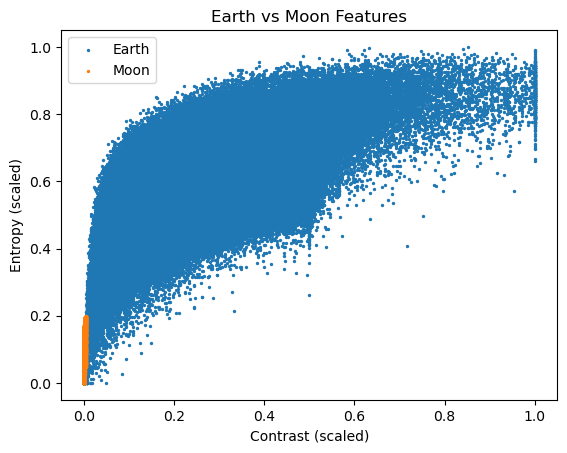

In [44]:
plt.scatter(earth_scaled[:,0], earth_scaled[:,1], s=2, label="Earth")
plt.scatter(moon_scaled[:,0], moon_scaled[:,1], s=2, label="Moon")
plt.xlabel("Contrast (scaled)"); plt.ylabel("Entropy (scaled)"); plt.legend(); plt.title("Earth vs Moon Features")
plt.show()

=== Reading Excel File ===
Sheets found: ['Sheet1']

--- Sheet: 'Sheet1' ---
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']
                                      Unnamed: 0   Unnamed: 1 Unnamed: 2   Unnamed: 3
0  Jump to Apollo:   11   12   14   15   16   17          NaN        NaN          NaN
1                                            NaN          NaN        NaN          NaN
2                                      Apollo 11          NaN        NaN          NaN
3                                  Sample Number  Sample Type  Lithology  Description

✅ Best sheet: 'Sheet1', skiprows=4, lith col='Sample Number'

Normalized columns: ['sample_number', 'sample_type', 'lithology', 'description']
  sample_number sample_type lithology                                                                                                                                         description
0         10000         NaN       NaN                                                            

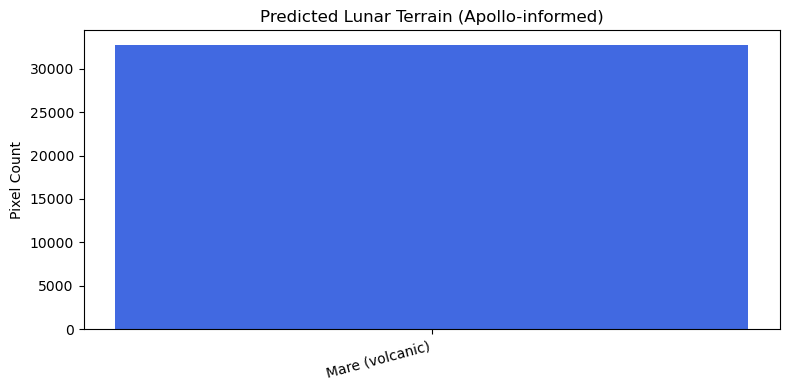

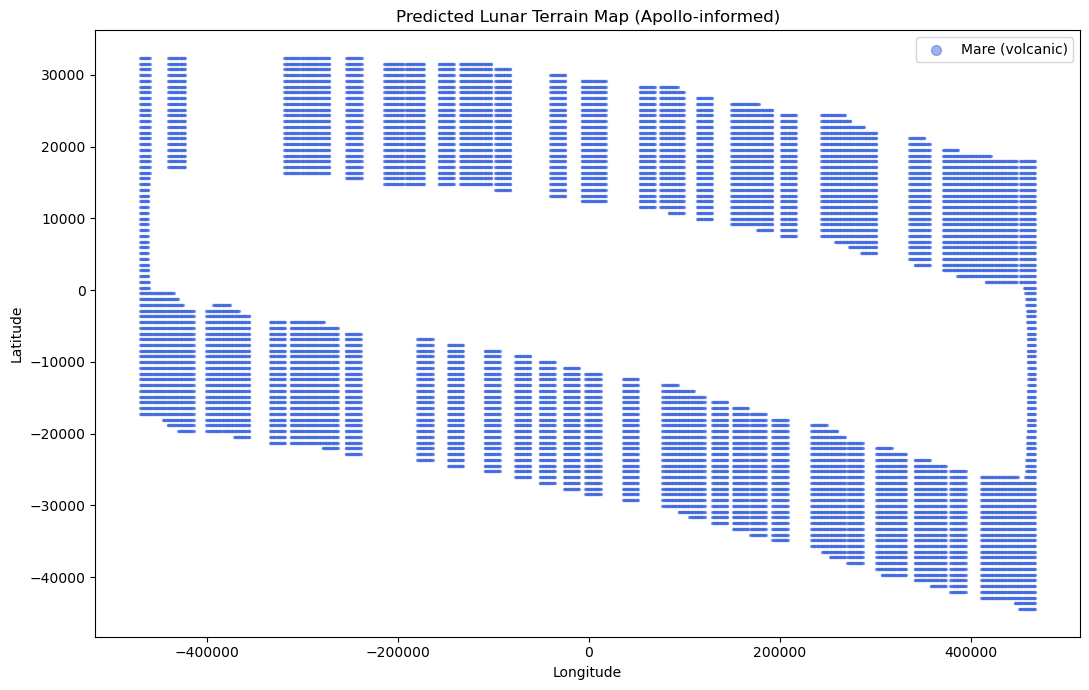

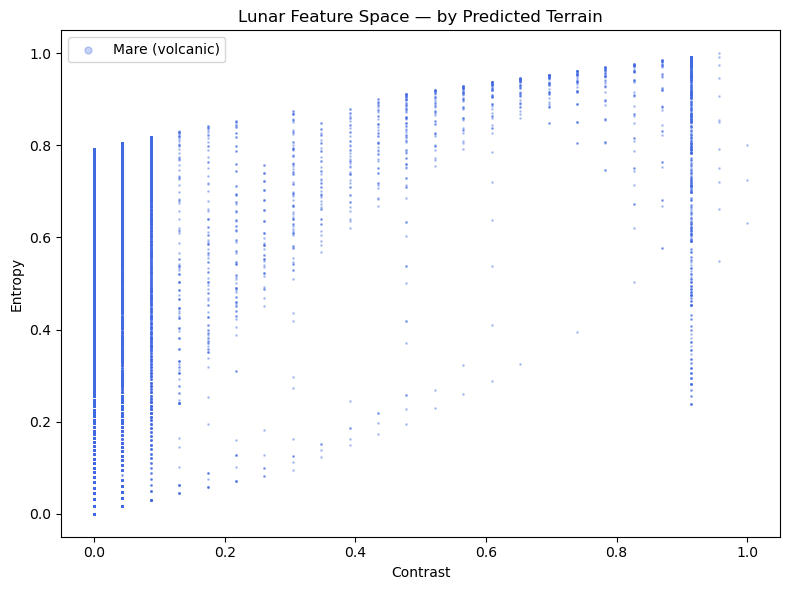


✅ DONE — files saved:
   → lunar_terrain_apollo_predicted.csv
   → apollo_clean_labels.csv
   → apollo_terrain_distribution.png
   → apollo_lunar_terrain_map.png
   → apollo_feature_space.png


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# =============================
# PATHS
# =============================
APOLLO_XLSX = r"G:\Satellite Data & Analysis\Lithological survey\CORRELATION\luna samples lihtology.xlsx"
LUNAR_CSV   = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\lunar_glcm_clusters_NO_THRESHOLD.csv"
EARTH_FEAT  = r"F:\SATELLITE ANALYSIS\Lunar\MINI-RF\earth_VV_VH_features_FINAL.csv"

# =============================
# STEP 1: DIAGNOSE EXCEL FILE
# Print all sheets and first few rows of each
# =============================
print("=== Reading Excel File ===")
xl = pd.ExcelFile(APOLLO_XLSX)
print(f"Sheets found: {xl.sheet_names}")

# Preview every sheet
all_sheets = {}
for sheet in xl.sheet_names:
    try:
        df = pd.read_excel(APOLLO_XLSX, sheet_name=sheet, nrows=6)
        print(f"\n--- Sheet: '{sheet}' ---")
        print("Columns:", df.columns.tolist())
        print(df.head(4).to_string())
        all_sheets[sheet] = df
    except Exception as e:
        print(f"Could not read sheet '{sheet}': {e}")

# =============================
# STEP 2: SMART LOAD — tries every sheet, finds the one with lithology data
# =============================
def find_col(df, keywords):
    for col in df.columns:
        for kw in keywords:
            if kw in str(col).lower():
                return col
    return None

best_df    = None
best_sheet = None

for sheet in xl.sheet_names:
    for skip in range(5):
        try:
            df = pd.read_excel(APOLLO_XLSX, sheet_name=sheet, skiprows=skip)
            df.columns = [str(c).strip() for c in df.columns]
            # Look for any column that has lithology-related content
            lith_col = find_col(df, ["litho", "lith", "rock", "type", "sample"])
            if lith_col is not None and len(df) > 2:
                print(f"\n✅ Best sheet: '{sheet}', skiprows={skip}, lith col='{lith_col}'")
                best_df    = df
                best_sheet = sheet
                break
        except Exception:
            continue
    if best_df is not None:
        break

if best_df is None:
    raise RuntimeError(
        "Could not find lithology data in any sheet.\n"
        "Check the sheet preview printed above and paste it here."
    )

apollo_raw = best_df.copy()

# =============================
# STEP 3: NORMALIZE COLUMN NAMES
# =============================
apollo_raw.columns = (
    apollo_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)
print("\nNormalized columns:", apollo_raw.columns.tolist())
print(apollo_raw.head(5).to_string())

# =============================
# STEP 4: AUTO-DETECT KEY COLUMNS
# =============================
col_lithology   = find_col(apollo_raw, ["litho", "lith"])
col_sample_type = find_col(apollo_raw, ["sample_type", "sampletype", "type"])
col_description = find_col(apollo_raw, ["desc", "note", "comment"])

print(f"\nDetected lithology col  : '{col_lithology}'")
print(f"Detected sample_type col: '{col_sample_type}'")
print(f"Detected description col: '{col_description}'")

# =============================
# STEP 5: BUILD UNIFIED LITHOLOGY COLUMN
# =============================
apollo_raw["_litho"] = ""

if col_lithology:
    apollo_raw["_litho"] = apollo_raw[col_lithology].astype(str).str.strip()

if col_sample_type:
    mask = apollo_raw["_litho"].isin(["nan", "", "none", "NaN", "—", "-"])
    apollo_raw.loc[mask, "_litho"] = apollo_raw.loc[mask, col_sample_type].astype(str).str.strip()

if col_description:
    mask = apollo_raw["_litho"].isin(["nan", "", "none", "NaN", "—", "-"])
    apollo_raw.loc[mask, "_litho"] = (
        apollo_raw.loc[mask, col_description]
        .astype(str).str.split().str[0]
    )

apollo_raw["_litho"] = apollo_raw["_litho"].str.lower().str.strip()

print("\n=== Raw lithology values (top 25) ===")
print(apollo_raw["_litho"].value_counts().head(25))

# =============================
# STEP 6: MAP TO TERRAIN CLASS
# =============================
def map_lithology(lith):
    lith = str(lith).lower()
    if any(x in lith for x in ["basalt", "mare", "volcanic",
                                 "ilmenite", "pyroxene", "olivine basalt"]):
        return "Mare (volcanic)"
    elif any(x in lith for x in ["anorthosite", "highland", "norite",
                                   "troctolite", "gabbro", "ferroan",
                                   "plagioclase", "anorth"]):
        return "Highlands (ancient crust)"
    elif any(x in lith for x in ["breccia", "impact", "melt",
                                   "fragmental", "impact melt"]):
        return "Impact / Breccia"
    elif any(x in lith for x in ["soil", "core", "fines",
                                   "glass", "regolith", "dust", "rake"]):
        return "Regolith / Soil"
    else:
        return "Unknown"

apollo_raw["terrain_class"] = apollo_raw["_litho"].apply(map_lithology)

print("\n=== Terrain Class Distribution ===")
print(apollo_raw["terrain_class"].value_counts())

apollo_clean = apollo_raw[
    (apollo_raw["terrain_class"] != "Unknown") &
    (~apollo_raw["_litho"].isin(["nan", "", "none", "—", "-"]))
].copy()

print(f"\nUsable Apollo samples: {len(apollo_clean)}")

# =============================
# STEP 7: WARN IF NOTHING MAPPED
# =============================
if len(apollo_clean) == 0:
    print("\n⚠️  No samples mapped to terrain classes.")
    print("    The lithology values printed above don't match any keywords.")
    print("    Paste those values here and we will add them to the mapping.")
else:
    # =============================
    # STEP 8: LOAD EARTH + FIT SCALER
    # =============================
    print("\n=== Loading Earth SAR Features ===")
    earth_df = pd.read_csv(EARTH_FEAT)
    earth_df["contrast"] = (earth_df["VV_contrast"] + earth_df["VH_contrast"]) / 2
    earth_df["entropy"]  = (earth_df["VV_entropy"]  + earth_df["VH_entropy"])  / 2
    scaler = MinMaxScaler()
    scaler.fit(earth_df[["contrast", "entropy"]].values)
    print("✅ Scaler fitted")

    # =============================
    # STEP 9: LOAD LUNAR GLCM
    # =============================
    print("\n=== Loading Lunar GLCM Data ===")
    lunar_df = pd.read_csv(LUNAR_CSV)
    rename_map = {}
    if "contrast_norm" in lunar_df.columns: rename_map["contrast_norm"] = "contrast"
    if "entropy_norm"  in lunar_df.columns: rename_map["entropy_norm"]  = "entropy"
    lunar_df = lunar_df.rename(columns=rename_map)
    print(f"Lunar rows    : {len(lunar_df)}")
    print(f"Lunar contrast: {lunar_df['contrast'].min():.4f} → {lunar_df['contrast'].max():.4f}")
    print(f"Lunar entropy : {lunar_df['entropy'].min():.4f}  → {lunar_df['entropy'].max():.4f}")
    moon_scaled = scaler.transform(lunar_df[["contrast", "entropy"]].values)

    # =============================
    # STEP 10: SYNTHETIC TRAINING
    # =============================
    terrain_feature_profile = {
        "Mare (volcanic)":           [0.15, 0.08, 0.25, 0.08],
        "Highlands (ancient crust)": [0.75, 0.10, 0.75, 0.10],
        "Impact / Breccia":          [0.55, 0.12, 0.55, 0.12],
        "Regolith / Soil":           [0.35, 0.10, 0.40, 0.10],
    }
    np.random.seed(42)
    synth_rows = []
    for _, row in apollo_clean.iterrows():
        cls = row["terrain_class"]
        if cls not in terrain_feature_profile:
            continue
        c_mu, c_sd, e_mu, e_sd = terrain_feature_profile[cls]
        for c, e in zip(
            np.random.normal(c_mu, c_sd, 50).clip(0, 1),
            np.random.normal(e_mu, e_sd, 50).clip(0, 1)
        ):
            synth_rows.append({"contrast_s": c, "entropy_s": e, "terrain_class": cls})

    synth_df = pd.DataFrame(synth_rows)
    print(f"\nSynthetic training samples: {len(synth_df)}")
    print(synth_df["terrain_class"].value_counts())

    # =============================
    # STEP 11: TRAIN & PREDICT
    # =============================
    le = LabelEncoder()
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(
        synth_df[["contrast_s", "entropy_s"]].values,
        le.fit_transform(synth_df["terrain_class"])
    )
    lunar_df["terrain_pred"]       = le.inverse_transform(rf.predict(moon_scaled))
    lunar_df["terrain_confidence"] = rf.predict_proba(moon_scaled).max(axis=1)

    print("\n=== Predicted Terrain Distribution ===")
    print(lunar_df["terrain_pred"].value_counts())

    # =============================
    # STEP 12: PLOTS
    # =============================
    colors = {
        "Mare (volcanic)"           : "royalblue",
        "Highlands (ancient crust)" : "firebrick",
        "Impact / Breccia"          : "forestgreen",
        "Regolith / Soil"           : "goldenrod",
    }

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = lunar_df["terrain_pred"].value_counts()
    ax.bar(counts.index, counts.values,
           color=[colors.get(t, "gray") for t in counts.index])
    ax.set_title("Predicted Lunar Terrain (Apollo-informed)")
    ax.set_ylabel("Pixel Count")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig("apollo_terrain_distribution.png", dpi=150)
    plt.show()

    # Spatial map
    if "lon" in lunar_df.columns and "lat" in lunar_df.columns:
        fig2, ax2 = plt.subplots(figsize=(11, 7))
        for terrain, grp in lunar_df.groupby("terrain_pred"):
            ax2.scatter(grp["lon"], grp["lat"], s=2,
                        c=colors.get(terrain, "gray"),
                        label=terrain, alpha=0.5)
        ax2.set_xlabel("Longitude")
        ax2.set_ylabel("Latitude")
        ax2.set_title("Predicted Lunar Terrain Map (Apollo-informed)")
        ax2.legend(markerscale=5)
        plt.tight_layout()
        plt.savefig("apollo_lunar_terrain_map.png", dpi=150)
        plt.show()

    # Feature space
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    for terrain, grp in lunar_df.groupby("terrain_pred"):
        ax3.scatter(grp["contrast"], grp["entropy"], s=1,
                    c=colors.get(terrain, "gray"),
                    label=terrain, alpha=0.3)
    ax3.set_xlabel("Contrast")
    ax3.set_ylabel("Entropy")
    ax3.set_title("Lunar Feature Space — by Predicted Terrain")
    ax3.legend(markerscale=5)
    plt.tight_layout()
    plt.savefig("apollo_feature_space.png", dpi=150)
    plt.show()

    # =============================
    # STEP 13: SAVE
    # =============================
    lunar_df.to_csv("lunar_terrain_apollo_predicted.csv", index=False)
    apollo_clean[["_litho", "terrain_class"]].to_csv("apollo_clean_labels.csv", index=False)
    print("\n✅ DONE — files saved:")
    print("   → lunar_terrain_apollo_predicted.csv")
    print("   → apollo_clean_labels.csv")
    print("   → apollo_terrain_distribution.png")
    print("   → apollo_lunar_terrain_map.png")
    print("   → apollo_feature_space.png")